# Coursework 2: Robotic behavioural cloning from images and actuator data

## Description
For this coursework, you are required to develop a behaviour cloning model. Behaviour cloning is a technique for training robotic agents using a dataset of sequences of actions. Consider the supervised learning definition where we have a dataset of observatios $d=\{(x_{1},y_{1}),...,(x_{n},y_{n})\}$ and the aim is to learn a function: $f:\mathcal{X}\rightarrow\mathcal{Y}$. In this case, $\mathcal{X}$ is the set of "observations" that the robot makes and $\mathcal{Y}$ is the set of actions that the robot takes.

The dataset you have been provided with contains examples of robot arms being required to pickup objects or drop objects (given it has already picked the object up) in a specific place. The observation space ($\mathcal{X}$) consists of:
- "front_cam_ob": A 3rd person image of the scene 
- "mount_cam_ob": An image of the scene taken from a camera mounted on top of the robotic arm, looking down
- "ee_cartesian_pos_ob": The positional and orientation co-ordinates of the robotic arm
- "ee_cartesian_vel_ob": The velocity of position and orientation of the robotic arm
- "joint_pos_ob": The position of the gripper which opens and closes

The action space ($\mathcal{Y}$) consists of:
- Three co-ordinates defining how much to move the robotic arm
- An action defining whether to open, not to move or close the gripper

The dataset is split into "trajectories" i.e., sequences of:
- $x_{i}$: The front_cam_ob, mount_cam_ob, ee_cartesian_pos_ob, ee_cartesian_vel_ob, joint_pos_ob __at time point i__ 
- $y_{i}$: The action taken i.e., how to move the arm and the gripper __given the observations__ in $x_{i}$

More information on the dataset can be found at: https://github.com/clvrai/clvr_jaco_play_dataset?tab=readme-ov-file

### Task
Your task has been split into several questions, each exploring how to develop an appropriate model for learning $f:\mathcal{X}\rightarrow\mathcal{Y}$. The task will require you to:
- Question 1: Tune an end-to-end supervised learning model taking in the full set of observations and predicting actions: You will be required to evaluate a proposed deep learning architecture (which takes as input all of front_cam_ob, mount_cam_ob, ee_cartesian_pos_ob, ee_cartesian_vel_ob and joint_pos_ob and predict the two actions) and propose a new model which outperforms the existing model;
- Question 2: Define and evaluate a VAE model for performing self-supervised learning and tune it as best you can, to learn a latent representation that can be used as input to a downstream supervised model for behaviour cloning
- Question 3: Evaluate the performance of your model proposed in question 1 against your self-supervised VAE representations from question 2 (plus a supervised head) on the test set

### Pointers
Some helper functions have been provided for you including the following functionality:
- A training and validation loop capabale of:
  - Handling "half-precision" modelling;
  - Logging results to weights and biases;
- An eda template to help you visualise the data
- An evaluation template to help you load saved model checkpoints from weights and biases
- A preprocessing script to help you convert the data into train/validation and test splits;
  - In this preprocessing script, trajectories longer than 75 timesteps have been removed to ease the computational requirements of the task;
- A torch Dataset class capable of handling the multi-model nature of the data;
- A example collate_fn to use in Dataloaders

Additionally, it is strongly suggested to call ```torch.manual_seed(1)``` whenever you initialise your model (i.e., when you first create the model or call model.reset()). This will ensure the parameters are initialised at the same value each time.

### IMPORTANT
- You are __not__ allowed to use pre-trained models, developed outside of this coursework i.e., you could __not__ use a pre-trained YOLO model
- Questions have been marked under the title "Task", ensure that you answer/address all of the bullet points under these headings


## Data download
Download the data for the project from here: https://drive.usercontent.google.com/download?id=1tVSilmXhyQd8gxZAEhvKMnynw0qzRFSZ&authuser=0

Save the data locally at: ../data/all_play_data_diverse or in Google Collab at: /content/drive/MyDrive/comp0188_2425/cw2. Saving the data in these locations will ensure the proprocessing script provided runs correctly. If you would like to alter these locations, you can alter them in the config.py file of the provided comp0188_cw2 package via the ROOT_PATH global variable.

### transition_df.csv
You have additionally been provided with a csv called "transition_df.csv". This contains a row for each observation/action pair in the dataset and is used to generate the train/validation and test datasets for this task. Note that this csv contains all trajectories (even those over 75 timesteps). This csv might also be useful for EDA. The transition_df.csv should be placed in the same folder that you placed the raw data in (discussed above).

## Imports

The comp0188_cw2 contains some config functionality so that you can run the code in collab and locally (to test models)! When you first import the package, import the project_options and set the appropriate configs.
- project_options.collab = True will set the dataset directories for google collab whilst false will set suitable local directories
- project_options.debug = True will load a subset of data whilst False will load all of the data. 

__IMPORTANT__: Alterting these options __once you have loaded other functionality__ from comp0188_cw2 may result in unintended outcomes.

In [1]:
# COLLAB = False
# if COLLAB:
#     !pip install --force-reinstall git+https://github.com/joshuaspear/pymlrf.git
#     !pip install h5py
#     # !pip install wandb
#     !pip install torchinfo
#     !pip install jaxtyping
#     !pip install git+https://github.com/joshuaspear/comp0188_cw2_public.git
#     !pip install typeguard==2.13.3

In [2]:
# !pip install --force-reinstall git+ssh://git@github.com/joshuaspear/pymlrf.git
# !pip install --force-reinstall git+ssh://git@github.com/joshuaspear/pymlrf.git

# !pip install git+ssh://git@github.com/joshuaspear/comp0188_cw2_public.git
# !pip install torchinfo
# !pip install jaxtyping
# !pip install typeguard==2.13.3

Ignore the error: 
```ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.inflect 7.4.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.```

In [3]:
ROOT_PATH = "/cs/student/projects1/aibh/2024/gcosta/dlcw2/all_play_data_diverse"

In [ ]:
from comp0188_cw2 import project_options
project_options.collab = False
print(project_options.collab)
project_options.debug = False
print(project_options.debug)

False
False


In [5]:
# Add sys path for pymlrf, otherwise import doesn't work.
import sys
sys.path.append('/cs/student/msc/aibh/2024/gcosta/Modules/pymlrf-master/src')

In [6]:
import torch
import numpy as np
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import datetime
from pymlrf.Structs.torch import DatasetOutput
import copy

import pandas as pd
from comp0188_cw2.utils import load_all_files
from torchvision import transforms
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import datetime
from typing import List

from comp0188_cw2.config import (
    train_dh, val_dh, test_dh, WANDB_PROJECT
    )
from comp0188_cw2.models.CNNConfig import ConvolutionLayersConfig
from comp0188_cw2.models.base import BaseModel
from comp0188_cw2.models.JointCNNEncoder import JointCNNEncoder
from comp0188_cw2.models.CNN import CNN
from comp0188_cw2.models.MLP import MLP
from comp0188_cw2.Metric.WandBMetricOrchestrator import WandBMetricOrchestrator
from comp0188_cw2.Dataset.NpDictDataset import NpDictDataset
from comp0188_cw2.Loss.BalancedLoss import TrackerBalancedLoss
from comp0188_cw2 import logger
from comp0188_cw2.training.TrainingLoop import TorchTrainingLoop

from torchsummary import summary
import altair as alt

2025-01-02 09:30:30,828 - pymlrf - WARNING - pymlrf environment variable not set. Logging to file will not be performed (__init__.py:47)


In [7]:
print(train_dh.loc)

/cs/student/projects1/aibh/2024/gcosta/dlcw2/all_play_data_diverse/train


## Build the dataset
You will only need to perform this step __once__ for the full dataset and __once__ for the debug dataset for the entire coursework, both locally and in Google collab. In Google Collab, the data will be saved in your Google Drive.

In [8]:
from comp0188_cw2.Preprocessing import main
RUN_PREPROCESSING = False
if RUN_PREPROCESSING:
  main()

## Question 1: Tune an end-to-end supervised learning model taking in the full set of observations and predicting actions

In [9]:
_keys = [
    "actions",
    "front_cam_ob",
    "mount_cam_ob",
    "terminals",
    "ee_cartesian_pos_ob",
    "ee_cartesian_vel_ob",
    "joint_pos_ob"
    ]
train_nps = load_all_files(train_dh.loc,"train_[0-9]+.h5",keys=_keys)
val_nps = load_all_files(val_dh.loc,"val_[0-9]+.h5",keys=_keys)

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:10<00:00,  2.06s/it]


In [10]:
train_nps["front_cam_ob"].shape

(25469, 224, 224)

### Question 1.a Preprocessing
Most likely in machine learning pipelines, input data needs to be preprocessed before passing it to the model. This question requires you to specify the preprocessing that you will perform for the different types of data i.e., front_cam_ob, mount_cam_ob, ee_cartesian_pos_ob, ee_cartesian_vel_ob and joint_pos_ob. The dataset class provided in the associated "comp0188_cw2" package enables you to pass a dictionary of functions to preprocess each element of the observations and actions. The class expects a dictionary of transformations to apply to each input/output. 

#### Question 1.a.i Preprocessing steps (5 marks)

##### Task
- Complete the dictionaries below, specifying the type of transformations you wish to perform. For each element (of the observations and actions), you should __at least__ convert the output to a tensor thus, these transformations have been implemented for you. You may alter __any__ part of the code between the "INSERT YOUR CODE HERE" comments

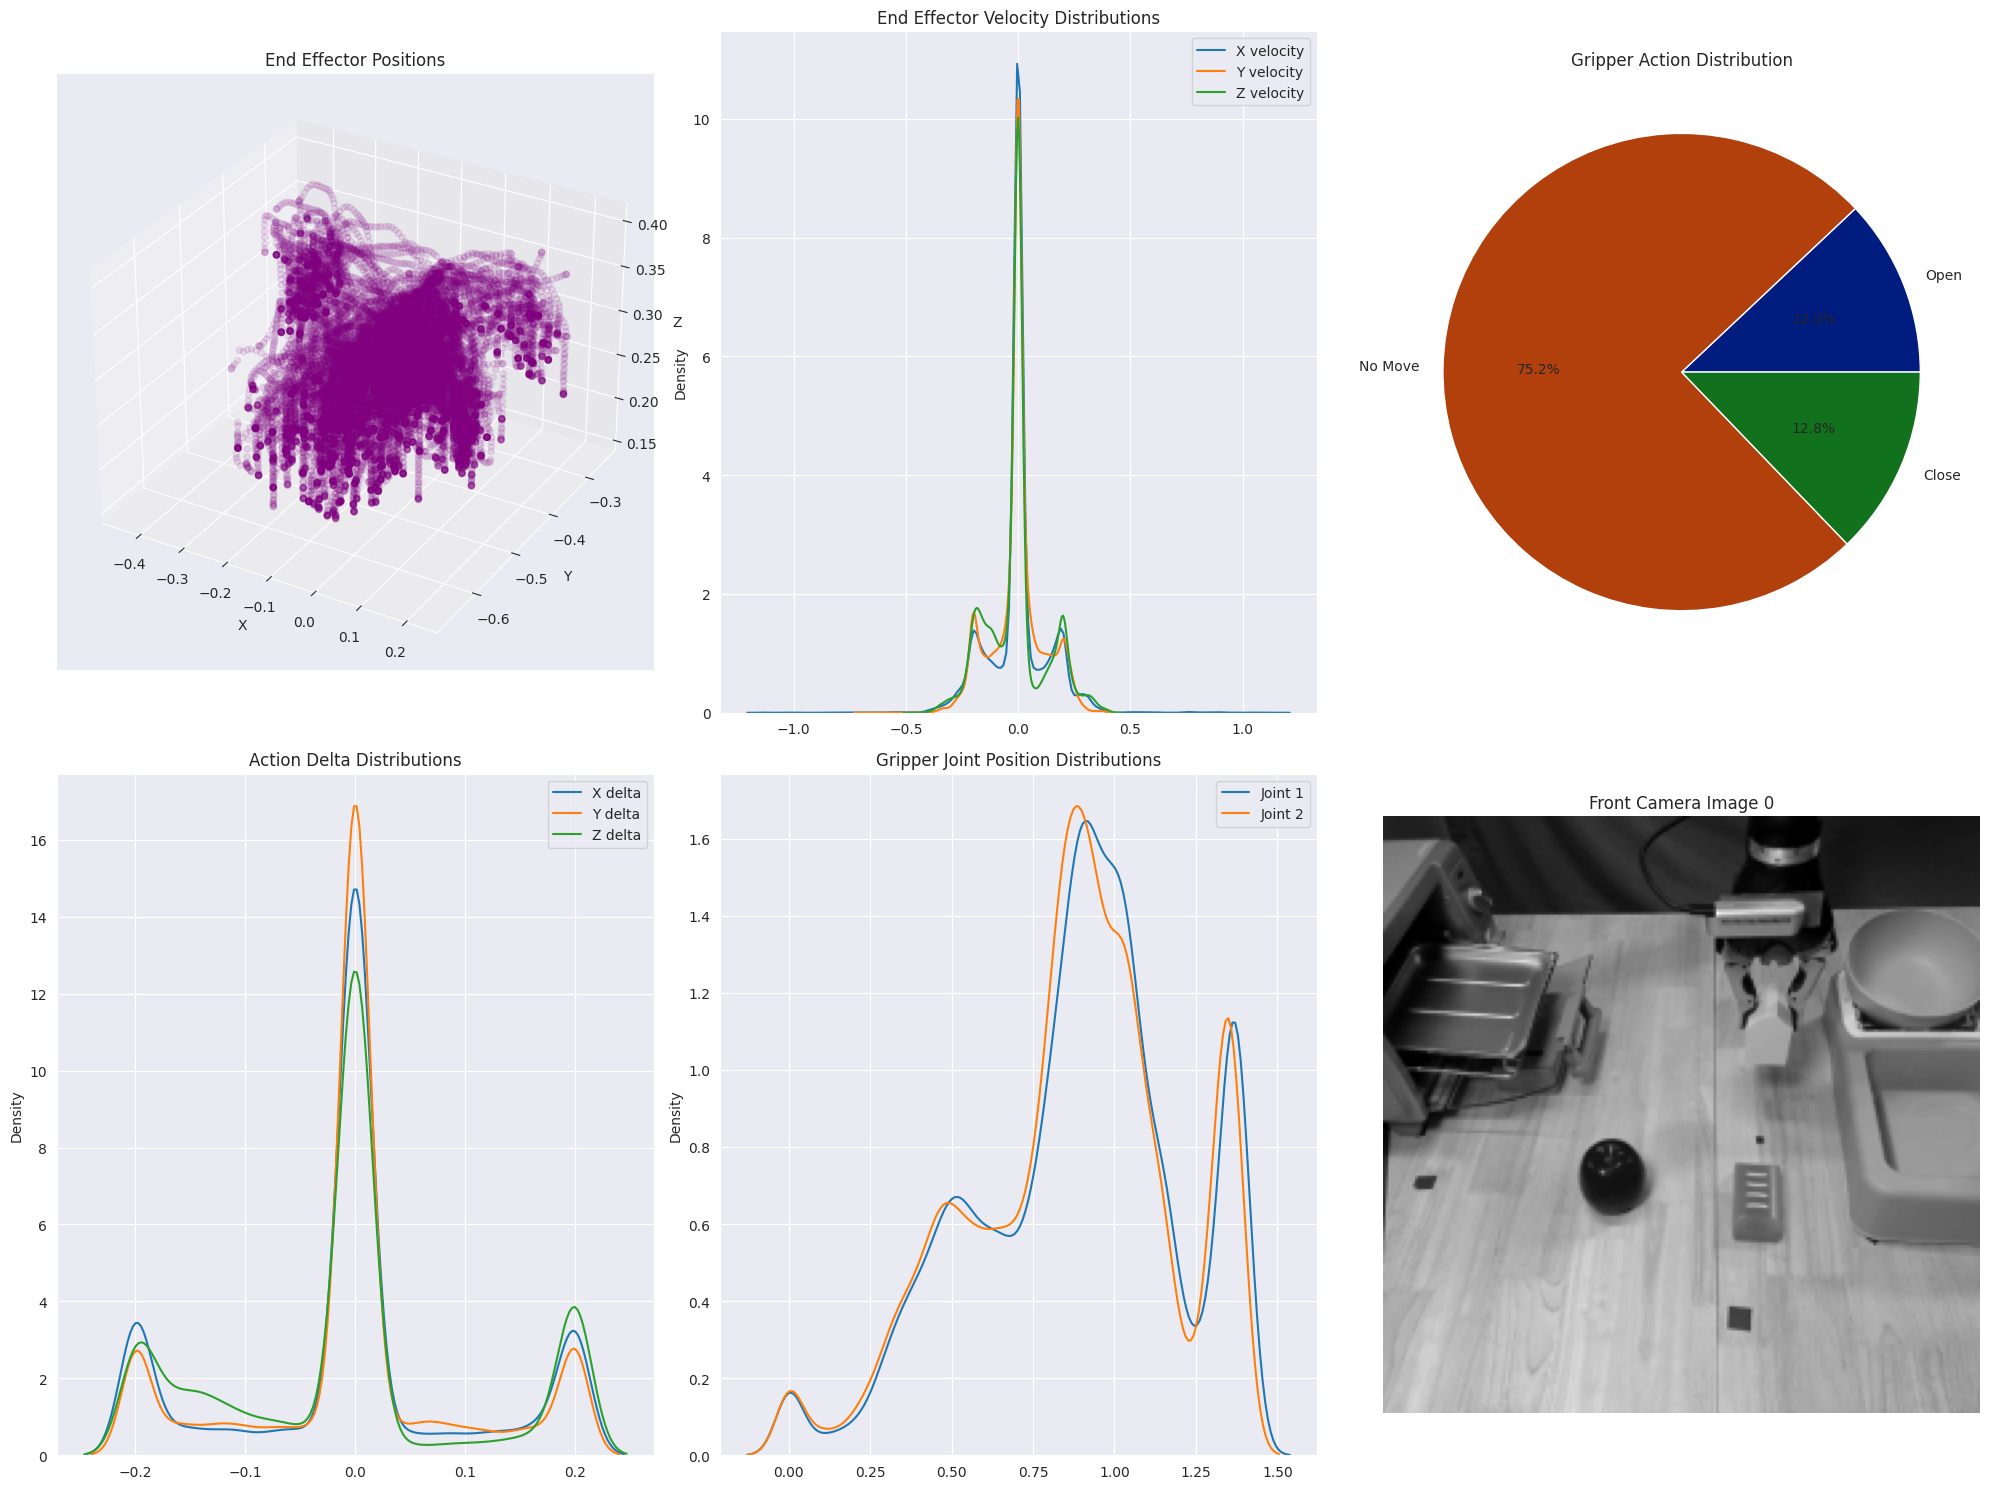

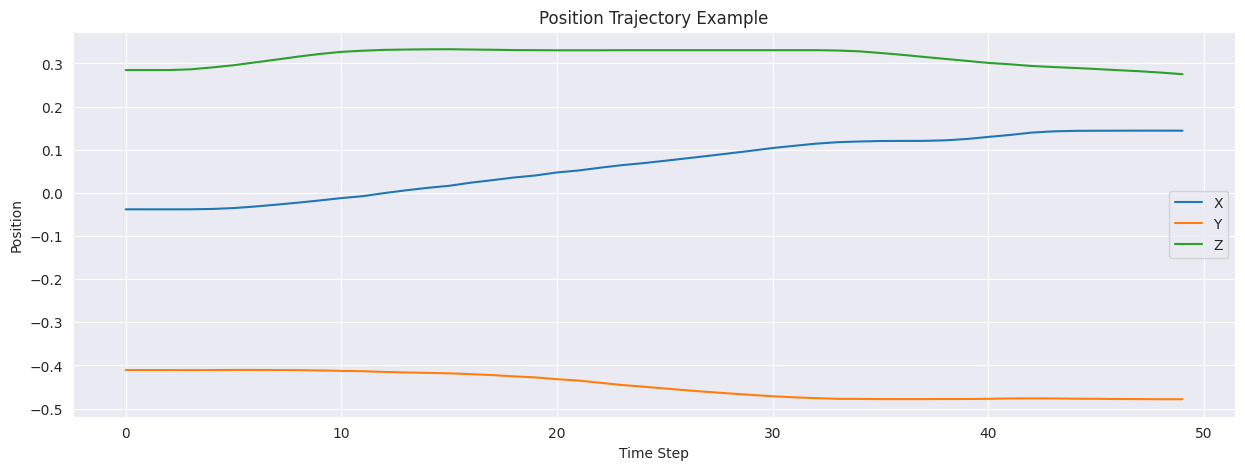

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
fig = plt.figure(figsize=(20, 15))

ax1 = fig.add_subplot(231, projection='3d')
positions = train_nps['ee_cartesian_pos_ob'][:, 0:3]
ax1.scatter(positions[:, 0], positions[:, 1], positions[:, 2], alpha=0.1, color="purple")
ax1.set_title('End Effector Positions')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

ax2 = fig.add_subplot(232)
velocities = train_nps['ee_cartesian_vel_ob'][:, 0:3]
for i, dim in enumerate(['X', 'Y', 'Z']):
    sns.kdeplot(velocities[:, i], label=f'{dim} velocity', ax=ax2)
ax2.set_title('End Effector Velocity Distributions')
ax2.legend()

ax3 = fig.add_subplot(233)
gripper_actions = train_nps['actions'][:, 3]
unique, counts = np.unique(gripper_actions, return_counts=True)
# sns.
colors = sns.color_palette('dark')

ax3.pie(counts, labels=['Open', 'No Move', 'Close'], autopct='%1.1f%%', colors=colors)
ax3.set_title('Gripper Action Distribution')

ax4 = fig.add_subplot(234)
deltas = train_nps['actions'][:, 0:3]
for i, dim in enumerate(['X', 'Y', 'Z']):
    sns.kdeplot(deltas[:, i], label=f'{dim} delta', ax=ax4)
ax4.set_title('Action Delta Distributions')
ax4.legend()

ax5 = fig.add_subplot(235)
joint_pos = train_nps['joint_pos_ob'][:, -2:] 
sns.kdeplot(joint_pos[:, 0], label='Joint 1', ax=ax5)
sns.kdeplot(joint_pos[:, 1], label='Joint 2', ax=ax5)
ax5.set_title('Gripper Joint Position Distributions')
ax5.legend()

ax6 = fig.add_subplot(236)
example_front = ((train_nps['front_cam_ob'][0] - train_nps['front_cam_ob'][0].min()) * 
                (255/(train_nps['front_cam_ob'][0].max() - train_nps['front_cam_ob'][0].min()))).astype('uint8')
ax6.imshow(example_front, cmap='gray')
ax6.set_title('Front Camera Image 0')
ax6.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
sequence_length = 50 
plt.plot(positions[:sequence_length, 0], label='X')
plt.plot(positions[:sequence_length, 1], label='Y')
plt.plot(positions[:sequence_length, 2], label='Z')
plt.title('Position Trajectory Example')
plt.xlabel('Time Step')
plt.ylabel('Position')
plt.legend()
plt.show()

In [12]:
# ******* INSERT YOUR CODE HERE *******
def normalize(x, min_val, max_val):
    """Normalize values to [0,1] range"""
    return (x - min_val) / (max_val - min_val)

# Calculate min/max values from training data
vel_min = train_nps['ee_cartesian_vel_ob'].min()
vel_max = train_nps['ee_cartesian_vel_ob'].max()
pos_min = train_nps['ee_cartesian_pos_ob'].min()
pos_max = train_nps['ee_cartesian_pos_ob'].max() 
joint_min = train_nps['joint_pos_ob'].min()
joint_max = train_nps['joint_pos_ob'].max()


#TODO: Maybe dont change scaling of the Y coordinate.
def action_transform(x):
    # Standardize coordinates 
    movement = torch.tensor(
        (x[0:3] - train_nps['actions'][:,0:3].mean(axis=0)) / 
        train_nps['actions'][:,0:3].std(axis=0)
    )
    #NOTE: Keep gripper as single integer value
    gripper = torch.tensor(int(x[3]), dtype=torch.long)  # Explicitly make it a long tensor for CrossEntropyLoss
    return torch.cat([movement, gripper.unsqueeze(0)])  # Keep 1D shape

"""Image means and stds"""
front_mean = (train_nps['front_cam_ob'].astype(np.float32) / 255.0).mean()
front_std = (train_nps['front_cam_ob'].astype(np.float32) / 255.0).std()
mount_mean = (train_nps['mount_cam_ob'].astype(np.float32) / 255.0).mean()
mount_std = (train_nps['mount_cam_ob'].astype(np.float32) / 255.0).std()

pos_tensor = torch.from_numpy(train_nps['ee_cartesian_pos_ob'])
vel_tensor = torch.from_numpy(train_nps['ee_cartesian_vel_ob'])
joint_tensor = torch.from_numpy(train_nps['joint_pos_ob'])

"""TRANSFORMS"""
global_transforms = {
    # IMAGE transforms - normalize to [0,1] and standardize
    "front_cam_ob": transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: (x / 255.0)),
        transforms.Normalize(
            mean=[float(front_mean)],  
            std=[float(front_std)]
        )
    ]),
    # IMAGE transforms - normalize to [0,1] and standardize
    "mount_cam_ob": transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: (x / 255.0)),        
        transforms.Normalize(
            mean=[float(mount_mean)],  
            std=[float(mount_std)]     
        )
    ]),
    # NORMALIZE position
    "ee_cartesian_pos_ob": lambda x: torch.tensor(
        normalize(x, pos_min, pos_max)
    ),    
    # STANDARDIZE velocities
    "ee_cartesian_vel_ob": lambda x: (torch.tensor(x) - vel_tensor.mean(dim=0)) / vel_tensor.std(dim=0),
    # NORMALIZE joint positions
    "joint_pos_ob": lambda x: torch.tensor(
        normalize(x, joint_min, joint_max)
    ),
    # action gets special treatment.
    "actions": lambda x: action_transform(x)
}

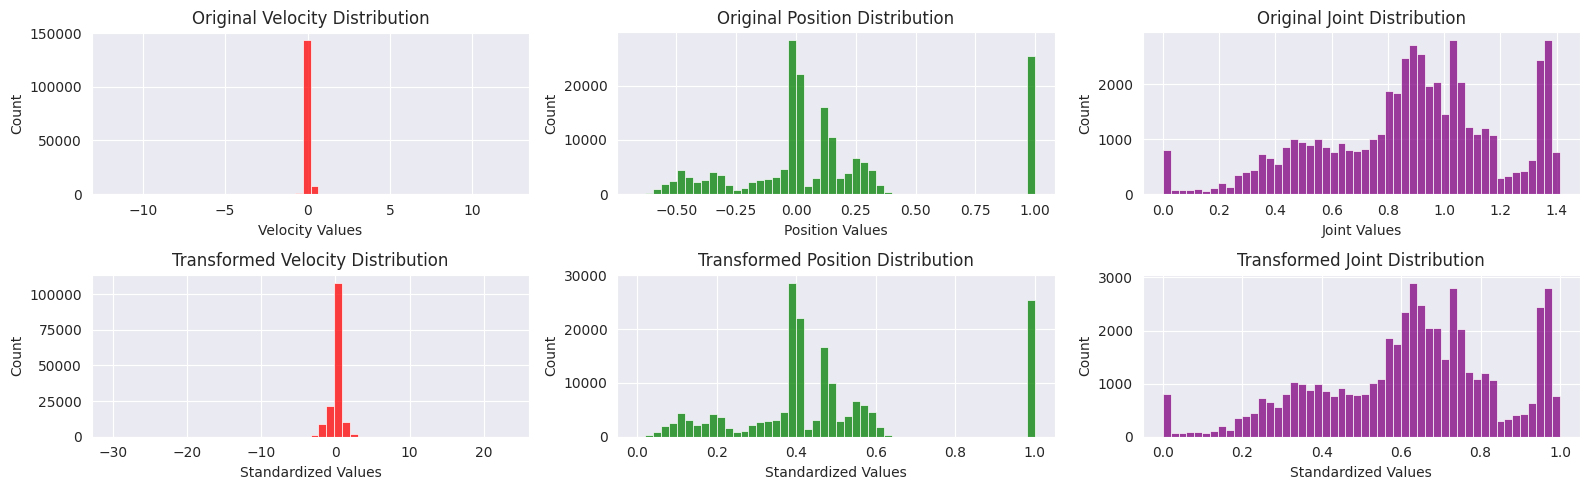


Summary Statistics:

Velocity:
Original - Mean: -0.003, Std: 0.295
Transformed - Mean: 0.000, Std: inf

Position:
Original - Mean: 0.124, Std: 0.411
Transformed - Mean: 0.474, Std: inf

Joint:
Original - Mean: 0.875, Std: 0.318
Transformed - Mean: 0.621, Std: 0.225


/cs/student/msc/aibh/2024/gcosta/.local/lib/python3.10/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
/cs/student/msc/aibh/2024/gcosta/.local/lib/python3.10/site-packages/numpy/_core/_methods.py:173: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 5))

vel_orig = train_nps['ee_cartesian_vel_ob'].flatten()
vel_transformed = np.vstack([
    global_transforms['ee_cartesian_vel_ob'](x).numpy() 
    for x in train_nps['ee_cartesian_vel_ob']
]).flatten()

sns.histplot(vel_orig, bins=50, ax=axes[0,0], color='red')
axes[0,0].set_title('Original Velocity Distribution')
axes[0,0].set_xlabel('Velocity Values')

sns.histplot(vel_transformed, bins=50, ax=axes[1,0], color='red')
axes[1,0].set_title('Transformed Velocity Distribution')
axes[1,0].set_xlabel('Standardized Values')

pos_orig = train_nps['ee_cartesian_pos_ob'].flatten()
pos_transformed = np.vstack([
    global_transforms['ee_cartesian_pos_ob'](x).numpy() 
    for x in train_nps['ee_cartesian_pos_ob']
]).flatten()

sns.histplot(pos_orig, bins=50, ax=axes[0,1], color='green')
axes[0,1].set_title('Original Position Distribution')
axes[0,1].set_xlabel('Position Values')

sns.histplot(pos_transformed, bins=50, ax=axes[1,1], color='green')
axes[1,1].set_title('Transformed Position Distribution')
axes[1,1].set_xlabel('Standardized Values')

joint_orig = train_nps['joint_pos_ob'].flatten()
joint_transformed = np.vstack([
    global_transforms['joint_pos_ob'](x).numpy()
    for x in train_nps['joint_pos_ob']
]).flatten()

sns.histplot(joint_orig, bins=50, ax=axes[0,2], color='purple')
axes[0,2].set_title('Original Joint Distribution')
axes[0,2].set_xlabel('Joint Values')

sns.histplot(joint_transformed, bins=50, ax=axes[1,2], color='purple')
axes[1,2].set_title('Transformed Joint Distribution')
axes[1,2].set_xlabel('Standardized Values')



plt.tight_layout()
plt.show()

print("\nSummary Statistics:")
print("\nVelocity:")
print(f"Original - Mean: {vel_orig.mean():.3f}, Std: {vel_orig.std():.3f}")
print(f"Transformed - Mean: {vel_transformed.mean():.3f}, Std: {vel_transformed.std():.3f}")

print("\nPosition:")
print(f"Original - Mean: {pos_orig.mean():.3f}, Std: {pos_orig.std():.3f}")
print(f"Transformed - Mean: {pos_transformed.mean():.3f}, Std: {pos_transformed.std():.3f}")

print("\nJoint:")
print(f"Original - Mean: {joint_orig.mean():.3f}, Std: {joint_orig.std():.3f}")
print(f"Transformed - Mean: {joint_transformed.mean():.3f}, Std: {joint_transformed.std():.3f}")

<h3>EDA pre and post transform

#### Question 1.a.ii Justification (5 marks)
##### Task
- In the markdown cell below, justify your decisions for preprocessing including where you have decided __not__ to apply preprocessing. You should include empirical evidence from your EDA analysis to support your decisions. Justfication __without__ evidence will be rewarded 0 marks.

_actions_: **There are three potential actions our robot arm can take [Open Gripper: 0, No Change: 1, Close Gripper: 2]. An action is an array of 4 values, the first three being a set of carterian deltas (X,Y,Z), and the last one the action [0-2]. We don't need to One Hot Encode the [0-2] action as it is ordinal. But we should standardize the movement delta coordinates, as neural networks generally do better with standardized values. The movements are already centered around 0 (since they are +/- changes). We shouldn't normalize these deltas because it might shrink small, but critical, movements. There is a signicant class imbalance in the action choices, but we will not influence that here.**

_front_cam_ob_: **Our image data has already been preprocessed into 224x224 grayscale images thanks to Josh. So the only thing we need to do is normalize each pixel to 0-1. As well as converting it to a tensor.** 

_mount_cam_ob_: **Same as front_cam_ob, just normalize and convert to tensor.**

_ee_cartesian_pos_ob_: **This data consists of 7 values: (x,y,z) + (w,x,y,z), that is, a cartesian and quaternion component. The quaternion is to avoid gimbal lock and is used in robotics a lot. Since these are continuous values we need to standardize them similar to the action deltas. Our Jaco Play robot already has limited bounds (play area), so normalizing is unecessary.**

_ee_cartesian_vel_ob_: **This consists of 6 values: a position (x,y,z) and a rotation (yaw, roll, pitch). These continuous values should be standardized and not normalized to preserve outlier information (which there is plenty of: see the above plots).**

_joint_pos_ob_: **This is a 2D vector representing the position of the joint for the gripper. It can only move in a 2D plane. Let's normalize it since the values are already bounded by the limits of the arm. Relative position changes are probably meaningful here.**

### Question 1.b End-to-end supervised model evaluation
The code below defines an end to end supervised model which: 
- Jointly encodes the two images ("front_cam_ob", "mount_cam_ob") using a CNN architecture (image_encoder);
- Seperately encoding the positional and velocity observations using an MLP;
- Combines the two embeddings by adding them together and;
- Passes the combined embedding into a final MLP layer (dense)
  
This question requires you to define sutable loss functions for the model and then evaluate the performance.

In [14]:
cnn2_config = ConvolutionLayersConfig(
    input_dim=224,
    input_channels=2,
    layers=[
        nn.Conv2d(
            in_channels=2,
            out_channels=8,
            kernel_size=(3,3),
            stride=1,
            padding=1,
            dilation=1
          ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2)),
        nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=(3,3),
            stride=1,
            padding=1
          ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2)),
        nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=(3,3),
            stride=1,
            padding=1
          ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2))
        ]
    )

_cnn_output_dim = cnn2_config.get_output_dims()
_cnn_output_channels = cnn2_config.get_output_channels()
_mlp_input_dim = int(
            (_cnn_output_dim[-1]*_cnn_output_dim[-1])*_cnn_output_channels[-1]
            )


image_encoder = JointCNNEncoder(
    cnn=CNN(cnn2_config),
    dense=MLP(
        input_dim=_mlp_input_dim,
        hidden_dims=[256],
        output_dim=128
        )
)

obs_encoder = MLP(
    input_dim = 15,
    hidden_dims = [256,256],
    output_dim = 128
)

dense = MLP(
    input_dim = 128,
    hidden_dims = [64,32],
    output_dim = 6
)

class Baseline1(BaseModel):
  def __init__(
      self,
      image_encoder:JointCNNEncoder,
      obs_encoder:MLP,
      dense:MLP
      ) -> None:
      super().__init__()
      self.image_encoder = image_encoder
      self.obs_encoder = obs_encoder
      self.dense = dense

  def forward(self, images, obs):
    _img_enc = self.image_encoder(images)
    _obs_enc = self.obs_encoder(obs)
    _dense_enc = self.dense(_img_enc+_obs_enc)
    pos = _dense_enc[:,0:3]
    grp = _dense_enc[:,3:]
    return {
        "pos": pos,
        "grp":grp
        }
  def reset(
      self,
      image_encoder_kwargs,
      obs_encoder_kwargs,
      dense_kwargs
      ):
    self.image_encoder.reset(**image_encoder_kwargs)
    self.obs_encoder.reset(**obs_encoder_kwargs)
    self.dense.reset(**dense_kwargs)

torch.manual_seed(1)
model = Baseline1(
    image_encoder=image_encoder,
    obs_encoder=obs_encoder,
    dense=dense
)

#### Question 1.b.i Loss definitions (3 marks)
For the model defined above, the proposed loss function is defined where the contribution of "pos_criterion" and "grp_criterion" are equally weighted and the mean of the two values loss are used to define the final loss. Furthermore, the loss for the positional actions is the MSE and the loss for grp_criterion is the CrossEntropyLoss.

##### Task:
- Justify why this composite loss function is reasonable. You should make reference to the range of values predicted by the deep learning model.

**Justification:**

**Since our actions are composed of two different sets of values, it makes sense to use a loss which respects the underlying data. Our network outputs 6 values: 3 continuous for position, 3 logits for gripper action.**

**MSE Loss (pos_criterion): The position component of our actions are continuous cartersian coordinates. The X, Y, Z delta movements have means near 0 and standard deviations around 1 . MSE loss is useful here because it penalizes large positional errors quadratically, which is critical here since even small deviations could cause the gripper to miss the target. Also, it handles the continuous nature of the coordinates which range approximately from -3 to 3.**

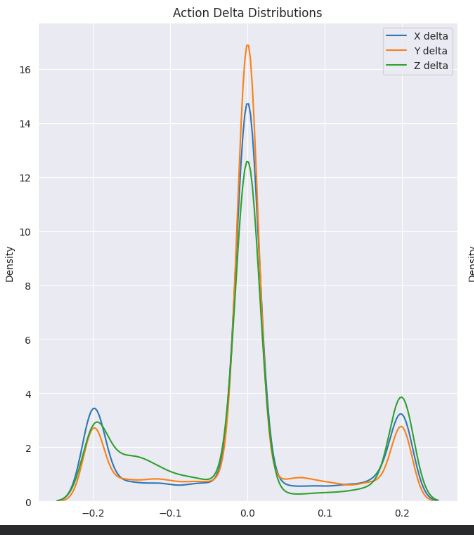

**Cross Entropy Loss (grp_criterion): This loss is ideal for classification with more than 2 output classes. It is especially useful for our gripper data because it handles class imbalances better than MSE Loss. The gripper classes are very imbalanced, with 75% No Change, 12% Open, 12% close. Moreover, CrossEntropyLoss is designed to interface with logits. It converts the logits into a distribution with softmax. And also computes the NLL of the correct class. Outputting logits rather than a distribution of probabilities is more reliable and stable.**

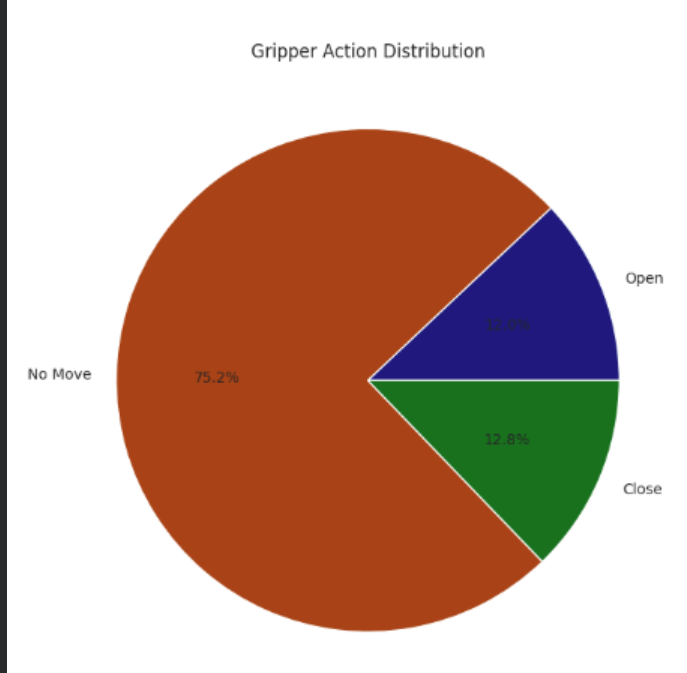
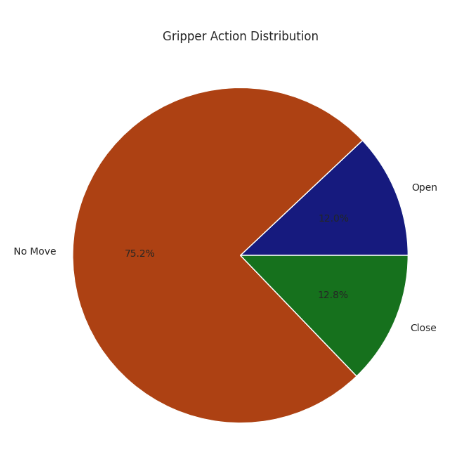

In [15]:
pos_criterion = nn.MSELoss(reduction="mean")
grp_criterion = nn.CrossEntropyLoss(reduction="mean")

In [16]:
torch.manual_seed(1)
model.reset({},{},{})
exp_kwargs = {
    "batch_size": 64,
    "learning_rate": 0.001,
    "half_precision": True,
    "target_offset": 0
}

if project_options.debug:
    exp_kwargs["batch_size"] = 4


if exp_kwargs["half_precision"]:
    train_dataset = NpDictDataset(
        array_dict=train_nps,
        transform_lkp = global_transforms,
        dep_vars = ["actions"],
        indep_vars = [
            "front_cam_ob","mount_cam_ob", "ee_cartesian_pos_ob",
            "ee_cartesian_vel_ob", "joint_pos_ob"
            ],
        target_offset=exp_kwargs["target_offset"]
        )

    val_dataset = NpDictDataset(
        array_dict=val_nps,
        transform_lkp = global_transforms,
        dep_vars = ["actions"],
        indep_vars = [
            "front_cam_ob","mount_cam_ob", "ee_cartesian_pos_ob",
            "ee_cartesian_vel_ob", "joint_pos_ob"
            ],
        target_offset=exp_kwargs["target_offset"]
        )
else:
    train_dataset = NpDictDataset(
        array_dict={k:train_nps[k].astype(np.float32) for k in train_nps},
        transform_lkp = global_transforms,
        dep_vars = ["actions"],
        indep_vars = [
            "front_cam_ob","mount_cam_ob", "ee_cartesian_pos_ob",
            "ee_cartesian_vel_ob", "joint_pos_ob"
            ],
        target_offset=exp_kwargs["target_offset"]
        )

    val_dataset = NpDictDataset(
        array_dict={k:val_nps[k].astype(np.float32) for k in val_nps},
        transform_lkp = global_transforms,
        dep_vars = ["actions"],
        indep_vars = [
            "front_cam_ob","mount_cam_ob", "ee_cartesian_pos_ob",
            "ee_cartesian_vel_ob", "joint_pos_ob"
            ],
        target_offset=exp_kwargs["target_offset"]
        )

print(len(train_dataset))
out = train_dataset[0]

def collate_func(input_list:List[DatasetOutput])->DatasetOutput:
    pos = []
    _grp = []
    images = []
    obs = []
    for val in input_list:
        images.append(
            torch.concat(
                [val.input["front_cam_ob"], val.input["mount_cam_ob"]],
                dim=0
            )[None,:]
            )
        obs.append(
            torch.concat(
                [
                    val.input["ee_cartesian_pos_ob"],
                    val.input["ee_cartesian_vel_ob"],
                    val.input["joint_pos_ob"]
                    ],
                dim=0
            )[None,:]
        )
        pos.append(val.output["actions"][0:3][None,:])
        _grp.append(val.output["actions"][-1:][None])
    _grp = torch.concat(_grp, dim=0)
    grp = torch.zeros(_grp.shape[0],3)
    grp[torch.arange(len(grp)), _grp.squeeze().int()] = 1
    return DatasetOutput(
        input = {
            "images":torch.concat(images,dim=0),
            "obs":torch.concat(obs,dim=0),
            },
        output = {
            "pos":torch.concat(pos, dim=0),
            "grp":grp
            }
    )


train_dataloader = DataLoader(
    train_dataset,
    batch_size=exp_kwargs["batch_size"],
    shuffle=True,
    collate_fn=collate_func,
    pin_memory=True,
    num_workers=4,
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=exp_kwargs["batch_size"],
    shuffle=False,
    collate_fn=collate_func,
    pin_memory=True,
    num_workers=4,    
)

first_batch = next(train_dataloader.__iter__())

input_dim = first_batch.input["images"].shape
print(input_dim)
input_dim = first_batch.input["obs"].shape
print(input_dim)
pos_dim = first_batch.output["pos"].shape
print(pos_dim)
grp_dim = first_batch.output["grp"].shape
print(grp_dim)

exp_kwargs["model_def"] = model.__repr__()


if exp_kwargs["half_precision"]:
    model = model.half()
optimizer = torch.optim.Adam(
    model.parameters(), lr=exp_kwargs["learning_rate"],
    eps=1e-04
    )

__criterion = TrackerBalancedLoss(
    loss_lkp={
        "pos":pos_criterion,
        "grp": grp_criterion
    }
    )

if exp_kwargs["half_precision"]:
    with torch.no_grad():
        if torch.cuda.is_available():
            model = model.cuda()
            with torch.autocast(device_type="cuda"):
                res = model(
                    images=first_batch.input["images"].cuda(),
                    obs=first_batch.input["obs"].cuda()
                    )
                first_batch.output["pos"] = first_batch.output["pos"].cuda()
                first_batch.output["grp"] = first_batch.output["grp"].cuda()
        else:
            with torch.autocast(device_type="cpu"):
                res = model(
                    images=first_batch.input["images"],
                    obs=first_batch.input["obs"]
                    )
else:
    with torch.no_grad():
        if torch.cuda.is_available():
            model = model.cuda()
            res = model(
                images=first_batch.input["images"].cuda(),
                obs=first_batch.input["obs"].cuda()
                )
            first_batch.output["pos"] = first_batch.output["pos"].cuda()
            first_batch.output["grp"] = first_batch.output["grp"].cuda()
        else:
            res = model(
                images=first_batch.input["images"],
                obs=first_batch.input["obs"]
                )
print(__criterion(res,first_batch.output))


25469


torch.Size([64, 2, 224, 224])
torch.Size([64, 15])
torch.Size([64, 3])
torch.Size([64, 3])
tensor(4.3594, device='cuda:0', dtype=torch.float16)


In [17]:

mo = WandBMetricOrchestrator()
import logging
logger = logging.getLogger()
logger.setLevel(logging.DEBUG)
logging.debug("test")

train_criterion = TrackerBalancedLoss(
    loss_lkp={
        "pos":copy.deepcopy(pos_criterion),
        "grp":copy.deepcopy(grp_criterion)
    },
    name="train",
    mo=mo
    )

val_criterion = TrackerBalancedLoss(
    loss_lkp={
        "pos":copy.deepcopy(pos_criterion),
        "grp":copy.deepcopy(grp_criterion)
    },
    name="val",
    mo=mo
    )

sl_trainer = TorchTrainingLoop(
    model=model, gpu=True, optimizer=optimizer, criterion=train_criterion,
    val_criterion=val_criterion, epochs=10, logger=logger,
    mo=WandBMetricOrchestrator(), half_precision=exp_kwargs["half_precision"],
    preds_save_type="csv", output_dir="results/baseline_preds"
)

wandb_name = "End_to_end_1"
wandb_grp="End_to_end"

if project_options.debug:
    wandb_name = f"{wandb_name}_DEBUG"

orig = datetime.datetime.now()
sl_trainer.training_loop(
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    wandb_proj=WANDB_PROJECT,
    wandb_grp=wandb_grp,
    # logger=logger,
    wandb_config=exp_kwargs,
    wandb_name=wandb_name,
    reset_kwargs={
        "image_encoder_kwargs": {},
        "obs_encoder_kwargs": {},
        "dense_kwargs": {}
    }
    )
post_train = datetime.datetime.now()


# Configure logger



DEBUG:root:test
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): api.wandb.ai:443
DEBUG:urllib3.connectionpool:https://api.wandb.ai:443 "POST /graphql HTTP/11" 200 None
DEBUG:urllib3.connectionpool:https://api.wandb.ai:443 "POST /graphql HTTP/11" 200 None
wandb: Currently logged in as: greggs-eater (greggs-eater-ucl). Use `wandb login --relogin` to force relogin
DEBUG:git.cmd:Popen(['git', 'cat-file', '--batch-check'], cwd=/cs/student/msc/aibh/2024/gcosta/Modules/COMP0188_DeepLearning, stdin=<valid stream>, shell=False, universal_newlines=False)


INFO:root:Running epochs: 10
INFO:root:Running training epoch
100%|██████████| 398/398 [00:32<00:00, 12.37it/s]
INFO:root:epoch 1	 training loss : 59.09375
INFO:root:Running validation
INFO:root:epoch 1	 validation loss : 1.1279296875 
INFO:root:Running training epoch
100%|██████████| 398/398 [00:32<00:00, 12.39it/s]
INFO:root:epoch 2	 training loss : 0.9541015625
INFO:root:Running validation
INFO:root:epoch 2	 validation loss : 1.0185546875 
INFO:root:Running training epoch
100%|██████████| 398/398 [00:31<00:00, 12.44it/s]
INFO:root:epoch 3	 training loss : 0.8203125
INFO:root:Running validation
INFO:root:epoch 3	 validation loss : 0.97900390625 
INFO:root:Running training epoch
100%|██████████| 398/398 [00:31<00:00, 12.46it/s]
INFO:root:epoch 4	 training loss : 0.744140625
INFO:root:Running validation
INFO:root:epoch 4	 validation loss : 0.98486328125 
INFO:root:Running training epoch
100%|██████████| 398/398 [00:32<00:00, 12.42it/s]
INFO:root:epoch 5	 training loss : 0.67138671875
I

epoch_train_loss,█▁▁▁▁▁▁▁▁▁
epoch_val_loss,▅▂▁▁▁▂▂▇▅█
grp_train_loss,█▅▅▄▆▆▄▄▅▆▃▄▄▃▅▄▄▄▃▃▃▃▃▃▂▂▃▃▃▁▂▂▁▂▂▁▁▂▁▂
grp_val_loss,▂▃▄▂▂▃▄▄▃▃▃▄▃▁▂▅▅▄▃▃▃▂▆▂▃▂▁▄▃▁▂▂▅▄▃▆▂█▁▇
pos_train_loss,▇▇█▆▄▂▆▅▅▃▄▃▄▄▆▅▄▄▃▃▃▃▂▃▃▃▂▃▂▁▂▃▆▂▂▂▂▂▂▃
pos_val_loss,▅▄▃▃▇▃▄▇▅▃▇▅▅▁▇▁▃▃▁▄▃▃▄▆▃▄▆▃▄▆▄▅▁▂▁▇▁▆█▃
epoch_train_loss,0.38232
epoch_val_loss,1.24414
grp_train_loss,0.26003
grp_val_loss,0.42721
pos_train_loss,0.1493


#### Question 1.b.ii Model evaluation (marks broken down in sub questions)
This question requires you to evaluate the perfomance of the model defined above by interpreting model training/validation metrics and investigating the specific failure modes of the model. Run the cells above which will train the model for 10 epochs. 

**IMPORTANT, for questions (1.b.ii.i, 1.b.ii.ii, 1.b.ii.ii)** 
- You are **not** expected to train a baseline model and you will be awarded **0 marks** for training such a model and evaluating performance against it. 
- Furthermore, when interpretting the metric(s) and justifying your conclusions, you will loose marks for failing to comment on striking results that are obvious to the marker.
- **Incorrect interpretations of metrics** will be **negatively penalised**
- Finally, where you have been asked for empirical evidence, but provide none, you will be awarded __0 marks__.

#### Question 1.b.ii.i Epoch selection (3 marks)
##### Task
- Select an appropriate epoch using a suitable method, provide __empirical evidence__ for your choice.

**Epoch Selection: Epoch 6 is where validation loss starts to increase and we see significant overfitting in the model.**

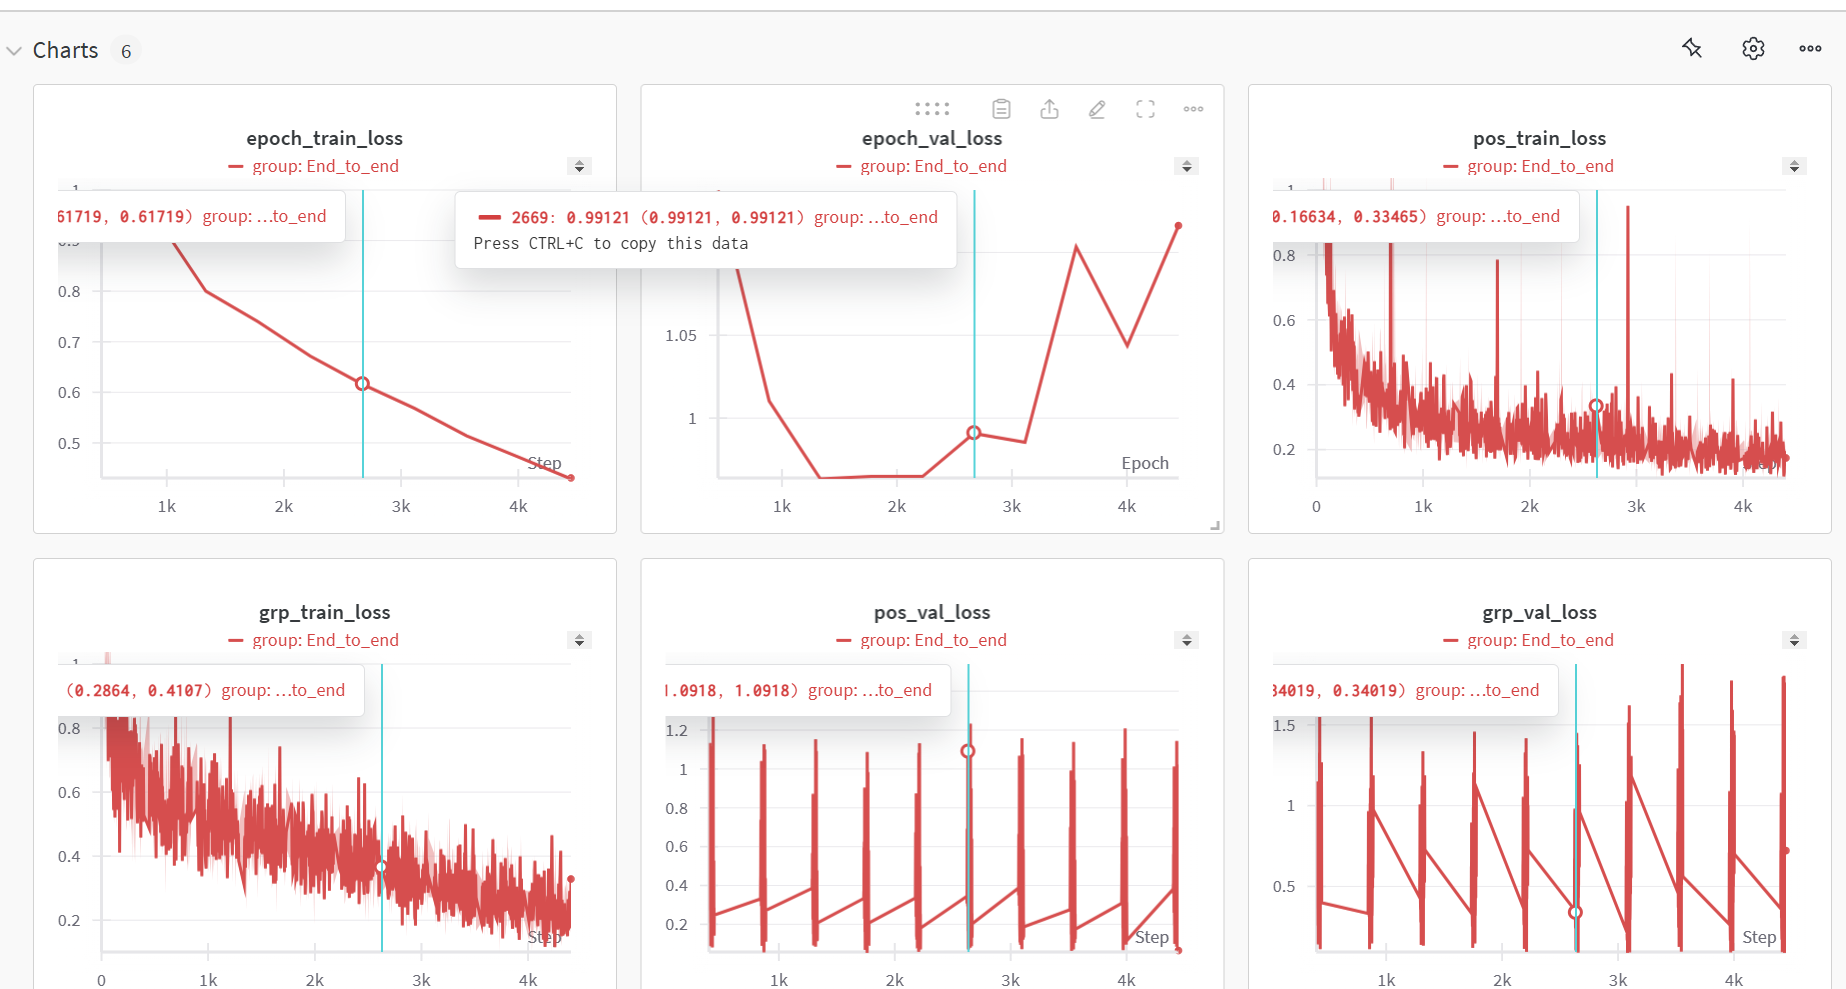

#### Question 1.b.ii.ii Performance evaluation (8 marks)
##### Task
- Draw conclusions regarding how well the model performs. To do this you may want to use additional metrics to the one(s) already reported. Critically, you should __contextualise__ the performance of the model. We are expecting discussion points a long the lines: _The model achieved a score of X according to metric Y. This suggests that the model is/is not performing well, because..._

**Performance Evaluation:**

** **

In [18]:
PREDS_PATH = '~/Modules/COMP0188_DeepLearning/COURSEWORK_2/results/baseline_preds/'

In [19]:
def load_prediction_files(epoch, pred_path):
    file_patterns = {
        'train_pos': f'epoch_{epoch}_train_preds_pos.csv',
        'train_grp': f'epoch_{epoch}_train_preds_grp.csv',
        'val_pos': f'epoch_{epoch}_val_preds_pos.csv',
        'val_grp': f'epoch_{epoch}_val_preds_grp.csv'
    }
    
    dfs = {}
    for key, filename in file_patterns.items():
        file_path = pred_path + filename
        dfs[key] = pd.read_csv(file_path)
        print(f"Loaded {key}: {dfs[key].shape} rows")
        
    return dfs

epoch_6_preds = load_prediction_files(6, PREDS_PATH)

# Access individual dataframes
train_pos_df = epoch_6_preds['train_pos']
train_grp_df = epoch_6_preds['train_grp']
val_pos_df = epoch_6_preds['val_pos']
val_grp_df = epoch_6_preds['val_grp']

Loaded train_pos: (25468, 3) rows
Loaded train_grp: (25468, 3) rows
Loaded val_pos: (2900, 3) rows
Loaded val_grp: (2900, 3) rows



Position Data Statistics:
-----------------------

train_pos Statistics:
                  x             y             z
count  25468.000000  25468.000000  25468.000000
mean       0.000736     -0.000643      0.000067
std        1.480624      1.346940      1.621705
min       -4.808594     -9.531250     -5.234375
25%       -0.335999     -0.415344     -0.972168
50%       -0.011250      0.008339      0.021042
75%        0.331299      0.442932      0.411682
max        4.937500      5.183594      7.542969

train_pos Correlations:
          x         y         z
x  1.000000 -0.010355  0.024700
y -0.010355  1.000000  0.060427
z  0.024700  0.060427  1.000000

val_pos Statistics:
                 x            y            z
count  2900.000000  2900.000000  2900.000000
mean      0.053007     0.195505     0.081940
std       1.434638     1.270025     1.550905
min      -4.226562    -3.365234    -4.292969
25%      -0.323792    -0.287354    -0.578369
50%       0.006430     0.171082     0.052521
75%  

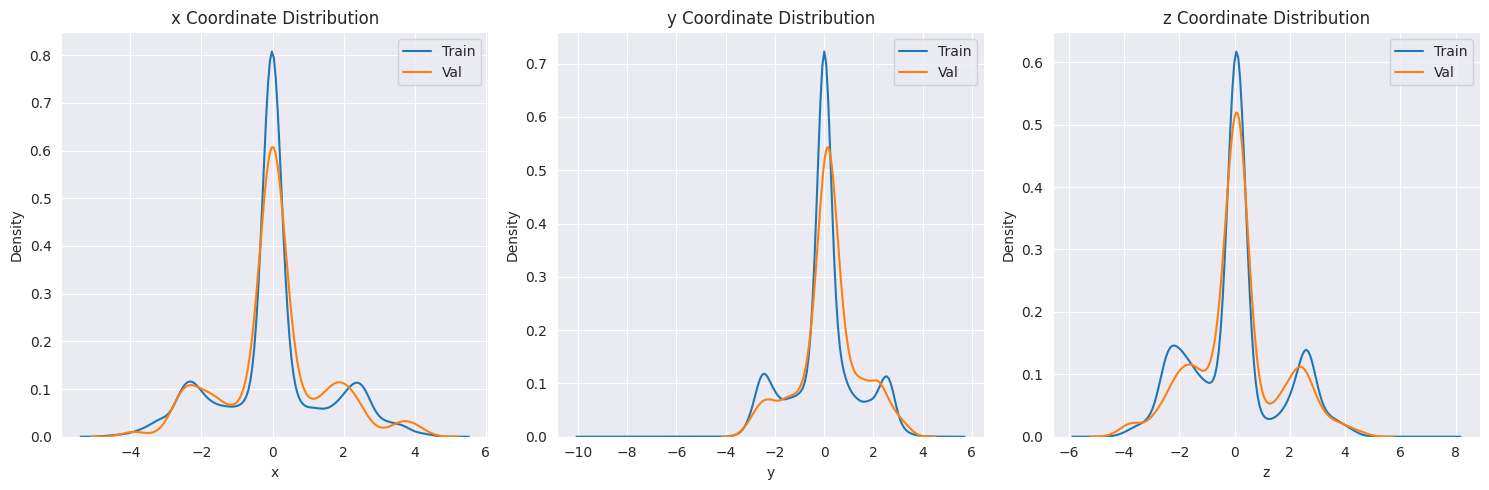

In [20]:
position_cols = ['x', 'y', 'z'] 
for key in ['train_pos', 'val_pos']:
    epoch_6_preds[key].columns = position_cols

print("\nPosition Data Statistics:")
print("-----------------------")
for key in ['train_pos', 'val_pos']:
    print(f"\n{key} Statistics:")
    print(epoch_6_preds[key].describe())
    
    print(f"\n{key} Correlations:")
    print(epoch_6_preds[key].corr())

plt.figure(figsize=(15, 5))

for i, coord in enumerate(position_cols):
    plt.subplot(1, 3, i+1)
    sns.kdeplot(data=epoch_6_preds['train_pos'][coord], label='Train')
    sns.kdeplot(data=epoch_6_preds['val_pos'][coord], label='Val')
    plt.title(f'{coord} Coordinate Distribution')
    plt.legend()

plt.tight_layout()
plt.show()


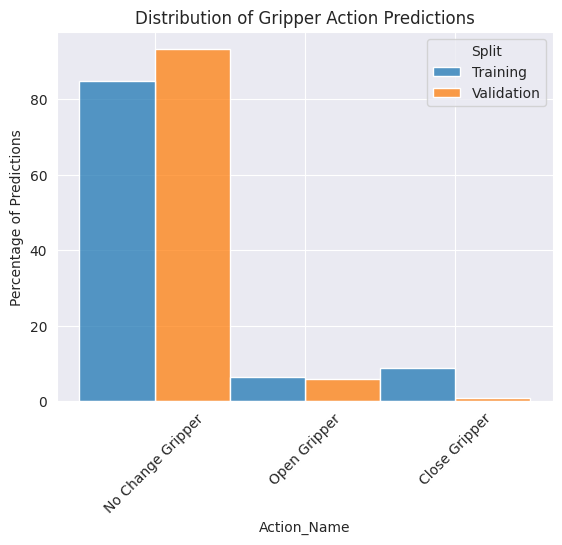

In [21]:
def get_predictions_df(grp_df, split='train'):
    """ LOGITS <=> PREDICTED CLASS """
    logits = torch.tensor(grp_df.values)
    predictions = torch.argmax(logits, dim=1)
    
    action_names = pd.Series(predictions.numpy()).map({
        0: 'Open Gripper',
        1: 'No Change Gripper', 
        2: 'Close Gripper'
    })
    
    return pd.DataFrame({
        'Action': predictions.numpy(),
        'Split': split,
        'Action_Name': action_names
    })

train_preds_df = get_predictions_df(epoch_6_preds['train_grp'], 'Training')
val_preds_df = get_predictions_df(epoch_6_preds['val_grp'], 'Validation')
all_preds = pd.concat([train_preds_df, val_preds_df])

sns.histplot(
    data=all_preds, 
    x='Action_Name', 
    hue='Split',
    multiple="dodge",
    stat='percent',
    common_norm=False 
)
plt.title('Distribution of Gripper Action Predictions')
plt.ylabel('Percentage of Predictions')
plt.xticks(rotation=45)
plt.show()

In [22]:
def calculate_performance_metrics(pos_df, grp_df):
    pos_mse = {
        'x': np.mean(pos_df['x']**2),
        'y': np.mean(pos_df['y']**2),
        'z': np.mean(pos_df['z']**2)
    }
    pos_std = {
        'x': np.std(pos_df['x']),
        'y': np.std(pos_df['y']),
        'z': np.std(pos_df['z'])
    }
    
    grp_predictions = np.argmax(grp_df.values, axis=1)
    action_counts = np.bincount(grp_predictions)
    action_percentages = action_counts / len(grp_predictions) * 100
    
    return {
        'position': {
            'mse': pos_mse,
            'std': pos_std
        },
        'gripper': {
            'action_distribution': action_percentages
        }
    }

val_metrics = calculate_performance_metrics(val_pos_df, val_grp_df)

print("\nValidation Set Metrics:")
print("\nPosition MSE:")
for coord, mse in val_metrics['position']['mse'].items():
    print(f"{coord}: {mse:.4f}")

print("\nPosition Standard Deviations:")
for coord, std in val_metrics['position']['std'].items():
    print(f"{coord}: {std:.4f}")

print("\nGripper Action Distribution:")
for i, pct in enumerate(val_metrics['gripper']['action_distribution']):
    action = 'Open' if i==0 else 'No Change' if i==1 else 'Close'
    print(f"{action}: {pct:.1f}%")


Validation Set Metrics:

Position MSE:
x: 2.0603
y: 1.6506
z: 2.4112

Position Standard Deviations:
x: 1.4344
y: 1.2698
z: 1.5506

Gripper Action Distribution:
Open: 6.0%
No Change: 93.1%
Close: 0.9%


<h3 style="color:orange">Performance Evaluation</h3>

1. **Gripper Action (grp) Performance:**
**- The model predicts actions with a distribution similar to the original distribution. Though "Close Gripper" seems to be largely absent from the validation predictions.**

2. **Carterisan Deltas (pos) Performance:**
**Using Mean Squared Error as a metric, we can evaluate the cartesian deltas.**
**The results are pretty bad:**
  - X-axis MSE: 2.06
  - Y-axis MSE: 1.65 (best performing)
  - Z-axis MSE: 2.41 (worst)

**Standard deviations are also quite high (1.23-1.55).  These errors are definitely concerning given that our input coordinates were standardized. This means are predictions are actually falling outside of the expected range.**

**The model is underperforming. For the gipper, the predictions are generally decent, except for the "Close Gripper" making up just 0.9% of the distribution (vs. the original of 10%). The positional predictions are much worse though, with high MSEs across the board for all axes. It could be that our cartesian deltas are being largely ignored and the prediction task is being dominated by the, simpler, gripper task.**

#### Question 1.b.ii.iii Model failure modes (9 marks)
##### Task
- Investigate the failure modes of the model. You should: 
  - Demonstrate the failure mode using **empirical evidence** e.g., _the model fails on X observations as demonstrated by..._
  - Assess the impact of these failure modes using **empirical evidence** i.e., how significant is this problem. You should consider both metrics and dataset coverage
  - Conclude __why__ the model might be failing on these observations **empirical evidence** e.g., _X part of the model performs poorly, as demonstrated by..._

__IMPORTANT__:
- Marks will be penalised if the failure modes you identify are not systematic i.e., you select a single observation that the model fails on. If you cannot identify any general failure modes of the model, you will be awarded full marks if you provide empirical evidence justifying why there are no systematic failure modes which sufficienty accounts for the diversity of observations in the dataset.


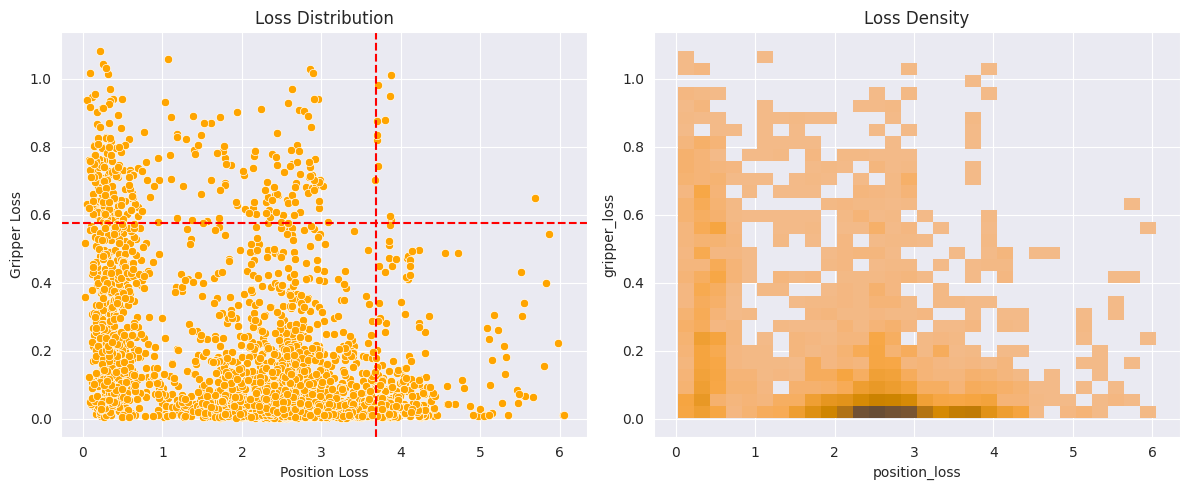


Failure Mode Analysis:
Total samples: 2900
High position loss samples: 290
High gripper loss samples: 290
Samples with both high losses: 11


In [ ]:
import torch.nn.functional as F 
def calculate_losses_per_sample():
    """ POS loss per SAMPLE"""
    pos_df = epoch_6_preds['val_pos']
    positions = torch.tensor(pos_df.values)
    pos_losses = torch.norm(positions, dim=1) 
    
    """ GRP (CrossEntropy for each sample) """
    grp_df = epoch_6_preds['val_grp']
    logits = torch.tensor(grp_df.values)
    probs = F.softmax(logits, dim=1)
    max_probs = torch.max(probs, dim=1).values
    grp_losses = -torch.log(max_probs)  
    
    
    loss_df = pd.DataFrame({
        'position_loss': pos_losses.numpy(),
        'gripper_loss': grp_losses.numpy()
    })
    
    pos_threshold = np.percentile(loss_df['position_loss'], 90)
    grp_threshold = np.percentile(loss_df['gripper_loss'], 90)
    
    loss_df['high_pos_loss'] = loss_df['position_loss'] > pos_threshold
    loss_df['high_grp_loss'] = loss_df['gripper_loss'] > grp_threshold
    
    return loss_df

loss_df = calculate_losses_per_sample()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=loss_df, x='position_loss', y='gripper_loss', color="orange")
plt.axvline(x=np.percentile(loss_df['position_loss'], 90), color='r', linestyle='--')
plt.axhline(y=np.percentile(loss_df['gripper_loss'], 90), color='r', linestyle='--')
plt.title('Loss Distribution')
plt.xlabel('Position Loss')
plt.ylabel('Gripper Loss')

plt.subplot(1, 2, 2)
sns.histplot(data=loss_df, x='position_loss', y='gripper_loss', bins=30, color="orange")
plt.title('Loss Density')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nFailure Mode Analysis:")
print(f"Total samples: {len(loss_df)}")
print(f"High position loss samples: {loss_df['high_pos_loss'].sum()}")
print(f"High gripper loss samples: {loss_df['high_grp_loss'].sum()}")
print(f"Samples with both high losses: {(loss_df['high_pos_loss'] & loss_df['high_grp_loss']).sum()}")

<h3 style="color:orange">Failure Modes</h3>

**We can try and see if there is any relation between the loss of our cartesian deltas and the grp loss by plotting. My hypothesis in the performance evaluation was that the gripper loss is dominating the predictions because it is a "simpler" task. In fact, there seems to be a negative correlation. Where high position loss (>2) leads to very low gripper loss. This is actually very in tune with my hypothesis. It seems the model is trading off position predictions for gripper accuracy. We might need to weight our losses somehow in the Model Tuning**

### Question 1.c Model tuning
Now you have evaluated the proposed model, you are required to iterate and train a higher performing one. You are expected to run experiments that help you understand where the model is underperforming, guiding your development.

#### Question 1.c.i Model tuning (5 marks)
##### Task
- Using the code blocks below, implement a model which improves over the previous. Improve the performance as best you can and report the results using the metric/metrics you used in question 1.b.ii Model evaluation. Markers should be able to retrain your model by running the cell below. You may however, reference previously defined objects (e.g., loaded data and use previously defined functions).

<h3 style="color:orange">Tuned Model Architecture

In [28]:

""" ++ ADD Skip Connection Blocks ++ """
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU() 
        
        self.skip = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
    
    def forward(self, x):
        out = self.bn1(x)
        out = self.relu(out)
        out = self.conv1(out)
        
        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv2(out)
        
        return out + self.skip(x)
    
            
def calculate_output_size(input_size, layers):
    size = input_size
    channels = 2 
    
    for layer in layers:
        if isinstance(layer, ResidualBlock):
            channels = layer.conv1.out_channels
        elif isinstance(layer, nn.MaxPool2d):
            size = size // 2  
    
    return size, channels    

cnn2_config = ConvolutionLayersConfig(
    input_dim=224,
    input_channels=2,
    layers=[
        ResidualBlock(2, 8),
        nn.MaxPool2d(kernel_size=(2,2)),
        nn.Dropout2d(0.2),  # ++ ADD DROPOUT ++ 
        
        ResidualBlock(8, 16),
        nn.MaxPool2d(kernel_size=(2,2)),
    ]
)

"""Output Dimensions"""
output_size, output_channels = calculate_output_size(224, cnn2_config.layers)
_mlp_input_dim = output_size * output_size * output_channels  # 28 * 28 * 32 = 25,088


image_encoder = JointCNNEncoder(
    cnn=CNN(cnn2_config),
    dense=MLP(
        input_dim=_mlp_input_dim,
        hidden_dims=[256],
        output_dim=128
    )
)

obs_encoder = MLP(
    input_dim = 15,
    hidden_dims = [256,256],
    output_dim = 128,
    dropouts = [0.2, 0.2], # ++ ADD DROPOUT ++ 
    batch_norms = [True, True],
    actvton = nn.ReLU()  
)

dense = MLP(
    input_dim = 128,
    hidden_dims = [64,32],
    output_dim = 6,
    dropouts = [0.2, 0.2], # ++ ADD DROPOUT ++  
    actvton = nn.ReLU()  
)
class ImprovedModel(BaseModel):
    def __init__(self, image_encoder, obs_encoder, dense):
        super().__init__()
        self.image_encoder = image_encoder
        self.obs_encoder = obs_encoder
        self.dense = dense
        
        self.img_norm = nn.LayerNorm(128)
        self.obs_norm = nn.LayerNorm(128)
        
        self.gate = nn.Sequential(
            nn.Linear(256, 128),
            nn.Sigmoid()
        )
        
    def forward(self, images, obs):
        img_enc = self.image_encoder(images)
        obs_enc = self.obs_encoder(obs)
        
        img_enc = self.img_norm(img_enc)
        obs_enc = self.obs_norm(obs_enc)
        
        combined = torch.cat([img_enc, obs_enc], dim=1)
        gates = self.gate(combined)
        
        features = gates * img_enc + (1 - gates) * obs_enc
        dense_out = self.dense(features)
        
        return {
            "pos": dense_out[:, :3],
            "grp": dense_out[:, 3:]
        }
    def reset(
        self,
        image_encoder_kwargs,
        obs_encoder_kwargs,
        dense_kwargs
    ):
        self.image_encoder.reset(**image_encoder_kwargs)
        self.obs_encoder.reset(**obs_encoder_kwargs)
        self.dense.reset(**dense_kwargs)
        
        
torch.manual_seed(1)
model = ImprovedModel(
    image_encoder=image_encoder,
    obs_encoder=obs_encoder,
    dense=dense
)

In [29]:
pos_criterion = nn.MSELoss(reduction="mean")
grp_criterion = nn.CrossEntropyLoss(reduction="mean")

In [30]:
torch.manual_seed(1)
model.reset({},{},{})
exp_kwargs = {
    "batch_size": 64,
    "learning_rate": 0.001,
    "half_precision": True,
    "target_offset": 0,
}

if project_options.debug:
    exp_kwargs["batch_size"] = 4


if exp_kwargs["half_precision"]:
    train_dataset = NpDictDataset(
        array_dict=train_nps,
        transform_lkp = global_transforms,
        dep_vars = ["actions"],
        indep_vars = [
            "front_cam_ob","mount_cam_ob", "ee_cartesian_pos_ob",
            "ee_cartesian_vel_ob", "joint_pos_ob"
            ],
        target_offset=exp_kwargs["target_offset"]
        )

    val_dataset = NpDictDataset(
        array_dict=val_nps,
        transform_lkp = global_transforms,
        dep_vars = ["actions"],
        indep_vars = [
            "front_cam_ob","mount_cam_ob", "ee_cartesian_pos_ob",
            "ee_cartesian_vel_ob", "joint_pos_ob"
            ],
        target_offset=exp_kwargs["target_offset"]
        )
else:
    train_dataset = NpDictDataset(
        array_dict={k:train_nps[k].astype(np.float32) for k in train_nps},
        transform_lkp = global_transforms,
        dep_vars = ["actions"],
        indep_vars = [
            "front_cam_ob","mount_cam_ob", "ee_cartesian_pos_ob",
            "ee_cartesian_vel_ob", "joint_pos_ob"
            ],
        target_offset=exp_kwargs["target_offset"]
        )

    val_dataset = NpDictDataset(
        array_dict={k:val_nps[k].astype(np.float32) for k in val_nps},
        transform_lkp = global_transforms,
        dep_vars = ["actions"],
        indep_vars = [
            "front_cam_ob","mount_cam_ob", "ee_cartesian_pos_ob",
            "ee_cartesian_vel_ob", "joint_pos_ob"
            ],
        target_offset=exp_kwargs["target_offset"]
        )

print(len(train_dataset))
out = train_dataset[0]

def collate_func(input_list:List[DatasetOutput])->DatasetOutput:
    pos = []
    _grp = []
    images = []
    obs = []
    for val in input_list:
        images.append(
            torch.concat(
                [val.input["front_cam_ob"], val.input["mount_cam_ob"]],
                dim=0
            )[None,:]
            )
        obs.append(
            torch.concat(
                [
                    val.input["ee_cartesian_pos_ob"],
                    val.input["ee_cartesian_vel_ob"],
                    val.input["joint_pos_ob"]
                    ],
                dim=0
            )[None,:]
        )
        pos.append(val.output["actions"][0:3][None,:])
        _grp.append(val.output["actions"][-1:][None])
    _grp = torch.concat(_grp, dim=0)
    grp = torch.zeros(_grp.shape[0],3)
    grp[torch.arange(len(grp)), _grp.squeeze().int()] = 1
    return DatasetOutput(
        input = {
            "images":torch.concat(images,dim=0),
            "obs":torch.concat(obs,dim=0),
            },
        output = {
            "pos":torch.concat(pos, dim=0),
            "grp":grp
            }
    )


train_dataloader = DataLoader(
    train_dataset,
    batch_size=exp_kwargs["batch_size"],
    shuffle=True,
    collate_fn=collate_func,
    pin_memory=True,
    num_workers=4
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=exp_kwargs["batch_size"],
    shuffle=False,
    collate_fn=collate_func,
    pin_memory=True,
    num_workers=4
)

first_batch = next(train_dataloader.__iter__())

input_dim = first_batch.input["images"].shape
print(input_dim)
input_dim = first_batch.input["obs"].shape
print(input_dim)
pos_dim = first_batch.output["pos"].shape
print(pos_dim)
grp_dim = first_batch.output["grp"].shape
print(grp_dim)

exp_kwargs["model_def"] = model.__repr__()


if exp_kwargs["half_precision"]:
    model = model.half()
    
optimizer = torch.optim.Adam(
    model.parameters(), lr=exp_kwargs["learning_rate"],
    eps=1e-03
    )

""" ++ ADD Learning Rate Scheduling  ++ """
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.1,
    min_lr=1e-6,
    verbose=True
)

__criterion = TrackerBalancedLoss(
    loss_lkp={
        "pos":pos_criterion,
        "grp":grp_criterion
    }
    )

if exp_kwargs["half_precision"]:
    with torch.no_grad():
        if torch.cuda.is_available():
            model = model.cuda()
            with torch.autocast(device_type="cuda"):
                res = model(
                    images=first_batch.input["images"].cuda(),
                    obs=first_batch.input["obs"].cuda()
                    )
                first_batch.output["pos"] = first_batch.output["pos"].cuda()
                first_batch.output["grp"] = first_batch.output["grp"].cuda()
        else:
            with torch.autocast(device_type="cpu"):
                res = model(
                    images=first_batch.input["images"],
                    obs=first_batch.input["obs"]
                    )
else:
    with torch.no_grad():
        if torch.cuda.is_available():
            model = model.cuda()
            res = model(
                images=first_batch.input["images"].cuda(),
                obs=first_batch.input["obs"].cuda()
                )
            first_batch.output["pos"] = first_batch.output["pos"].cuda()
            first_batch.output["grp"] = first_batch.output["grp"].cuda()
        else:
            res = model(
                images=first_batch.input["images"],
                obs=first_batch.input["obs"]
                )
print(__criterion(res,first_batch.output))


25469


torch.Size([64, 2, 224, 224])
torch.Size([64, 15])
torch.Size([64, 3])
torch.Size([64, 3])
tensor(4.3594, device='cuda:0', dtype=torch.float16)


/cs/student/msc/aibh/2024/gcosta/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


<h3 style="color:orange">Tuned Model Training

In [31]:
"""MODEL TRAINING  """

mo = WandBMetricOrchestrator()
import logging
logger = logging.getLogger()
logger.setLevel(logging.DEBUG)
logging.debug("test")

train_criterion = TrackerBalancedLoss(
    loss_lkp={
        "pos":copy.deepcopy(pos_criterion),
        "grp":copy.deepcopy(grp_criterion)
    },
    name="train",
    mo=mo
    )

val_criterion = TrackerBalancedLoss(
    loss_lkp={
        "pos":copy.deepcopy(pos_criterion),
        "grp":copy.deepcopy(grp_criterion)
    },
    name="val",
    mo=mo
    )

sl_trainer = TorchTrainingLoop(
    model=model, gpu=True, optimizer=optimizer, criterion=train_criterion,
    val_criterion=val_criterion, epochs=10, logger=logger,
    mo=WandBMetricOrchestrator(), half_precision=exp_kwargs["half_precision"],
    preds_save_type="csv", output_dir="results/tuned_preds",
    scheduler=scheduler,  # ++ ADD Scheduler ++
)

wandb_name = "End_to_end_2"
wandb_grp="End_to_end"

if project_options.debug:
    wandb_name = f"{wandb_name}_DEBUG"

orig = datetime.datetime.now()
sl_trainer.training_loop(
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    wandb_proj=WANDB_PROJECT,
    wandb_grp=wandb_grp,
    wandb_config=exp_kwargs,
    wandb_name=wandb_name,
    reset_kwargs={
        "image_encoder_kwargs": {},
        "obs_encoder_kwargs": {},
        "dense_kwargs": {}
    }
    )
post_train = datetime.datetime.now()


DEBUG:root:test


epoch_train_loss,▁
epoch_val_loss,▁
grp_train_loss,▇██▅▂▄▄▃▃▄▅▃▃▃▅▄▃▁▅▃▅▄▃▄▄▄▃▅▃▁▄▂▂▂▄▃▂▄▅▂
grp_val_loss,▂▄▂▆▅▃▂▂▁▂▂▂▁▂▂▂▃▂▅▄▂▂▂▃▄▄▃▄▁▂▂▃▂▃▃▂▃▂▃█
pos_train_loss,▆▄▆▇▅▅█▆▅▇▅▄▄▂▂▃▄▂▆▃▄▂▅▂▃▂▃▂▂▅▂▃▁▂▄▃▄▃▂▁
pos_val_loss,▃▃▃▆▂▁▃▇▄▄▂▂▂█▂▁▁▂▃▂▁▂▂▂▂▃▂▂▂▂▃▂▃▃▂▂▃▁▁▁
epoch_train_loss,0.98877
epoch_val_loss,0.54834
grp_train_loss,0.31989
grp_val_loss,0.02257
pos_train_loss,0.4552


DEBUG:git.cmd:Popen(['git', 'cat-file', '--batch-check'], cwd=/cs/student/msc/aibh/2024/gcosta/Modules/COMP0188_DeepLearning, stdin=<valid stream>, shell=False, universal_newlines=False)


INFO:root:Running epochs: 10
INFO:root:Running training epoch
100%|██████████| 398/398 [00:32<00:00, 12.31it/s]
INFO:root:epoch 1	 training loss : 0.99267578125
INFO:root:Running validation
INFO:root:epoch 1	 validation loss : 0.55078125 
INFO:root:Running training epoch
100%|██████████| 398/398 [00:32<00:00, 12.28it/s]
INFO:root:epoch 2	 training loss : 0.7822265625
INFO:root:Running validation
INFO:root:epoch 2	 validation loss : 0.548828125 
INFO:root:Running training epoch
100%|██████████| 398/398 [00:32<00:00, 12.29it/s]
INFO:root:epoch 3	 training loss : 0.71875
INFO:root:Running validation
INFO:root:epoch 3	 validation loss : 0.482666015625 
INFO:root:Running training epoch
100%|██████████| 398/398 [00:32<00:00, 12.38it/s]
INFO:root:epoch 4	 training loss : 0.68603515625
INFO:root:Running validation
INFO:root:epoch 4	 validation loss : 0.465576171875 
INFO:root:Running training epoch
100%|██████████| 398/398 [00:32<00:00, 12.33it/s]
INFO:root:epoch 5	 training loss : 0.667480468

epoch_train_loss,█▄▃▃▃▂▂▂▁▁
epoch_val_loss,██▄▃▂▃▁▂▂▂
grp_train_loss,▅▄▄▃▂▅▄▄▆▄▃▃▂▃▂▅▄▁▃▄▄▂▅▂▅▃▃▃▂█▂▂▁▁▃▄▂▅▂▄
grp_val_loss,▇▇▂▂▅▇▃▄▆▁▂▃▂▃▅▂▄▃▃█▂▂▄▃▃▃▂▂▂▅▂▂▄▂▁▅▄▃▁▄
pos_train_loss,█▃▅▃▂▃▄▂▃▂▂▂▃▃▂▂▃▂▂▂▁▂▂▂▁▂▂▂▂▁▂▁▁▂▁▁▁▂▁▁
pos_val_loss,▄▃▄▂▁▂▂▂▂▂▂▁▁▃▁▂▁▂▁▃█▂▂▂▂▁▂▂▃▁▂▁▁▁▁▂▁▁▂▂
epoch_train_loss,0.57471
epoch_val_loss,0.45142
grp_train_loss,0.24921
grp_val_loss,0.00657
pos_train_loss,0.30252


#### Question 1.c.ii Discussion (marks broken down in subsections below)

##### Task
In the markdown blocks below, discuss **three** experiments that you ran during the development of your model, defined in 1.c.i Model tuning which were the **most insightful** with respect to the design of your final model. Importantly, **most insightful** needn't necessarily be the final decisions that appear in the model defined in question 1.c.i Model tuning, rather they should be experiments that most shaped your model development process. For example: 
- You might decide to use a learning rate scheduler and decrease the learning rate at epoch 10 (call this experiment "EXP_LR");
- This experiment produces a jump in performance and unlocks a series of further fruitful experiments into learning rate scheduling;
- However, in the model reported in question 1.c.i Model tuning, you use a learning rate schedule with descreases at epochs 6 and 15 (since these produced a marginal performance over "EXP_LR")
- For this question __you should discuss EXP_LR__.
  
For each experiment, complete the "Description", "Result" and "Conclusion" sections where the following information should be provided:
* __Description__: What delta were you measuring i.e., change of architecture, change of learning rate etc?
* __Justification__: **Why** are you conducting the experiment?
  * What was the context of the model development process up to this point? What did you already know about how well the model performed/why it was performing/what were the challenging data points?
* __Conclusion__: What did you __learn__ from the experiment and provide __empirical evidence__ to support this claim. In drawing your conclusions, consider where there are multiple possible causes for the model failing, ensure you provide evidence for each of these and conclude whether or not they might be root cause (you may conclude that there are multiple causes).

**IMPORTANT** If your reported experiments are **not** well motivated and do not demonstrate that you have integrogated the model performance, you will be deducted marks. An example of poor motovation might be: *I chose to decrease the learning rate from X to Y as I did not know what impact this might have*. This justification could be improved by explaining what you __already know__ about how the learning rate might be affecting the model. What hypotheses might you draw about what the experiment will show?



In [32]:
TUNED_PREDS_PATH = '~/Modules/COMP0188_DeepLearning/COURSEWORK_2/results/tuned_preds/'

In [33]:
tuned_epoch_6_preds = load_prediction_files(6, TUNED_PREDS_PATH)

tuned_train_pos_df = tuned_epoch_6_preds['train_pos']
tuned_train_grp_df = tuned_epoch_6_preds['train_grp']
tuned_val_pos_df = tuned_epoch_6_preds['val_pos']
tuned_val_grp_df = tuned_epoch_6_preds['val_grp']

Loaded train_pos: (25468, 3) rows
Loaded train_grp: (25468, 3) rows
Loaded val_pos: (2900, 3) rows
Loaded val_grp: (2900, 3) rows



Position Data Statistics:
-----------------------

train_pos Statistics:
                  x             y             z
count  25468.000000  25468.000000  25468.000000
mean      -0.000230      0.001153      0.001548
std        1.470402      1.315501      1.581004
min       -4.457031     -4.523438     -4.160156
25%       -0.395508     -0.318359     -0.948853
50%        0.019966      0.003169      0.053284
75%        0.397522      0.357666      0.446533
max        4.550781      4.390625      4.917969

train_pos Correlations:
          x         y         z
x  1.000000 -0.029315  0.026610
y -0.029315  1.000000  0.065336
z  0.026610  0.065336  1.000000

val_pos Statistics:
                 x            y            z
count  2900.000000  2900.000000  2900.000000
mean     -0.059275     0.161634     0.029335
std       1.430801     1.235400     1.479048
min      -2.933594    -3.199219    -2.996094
25%      -0.228668    -0.041565    -0.429810
50%       0.013535     0.006918     0.063110
75%  

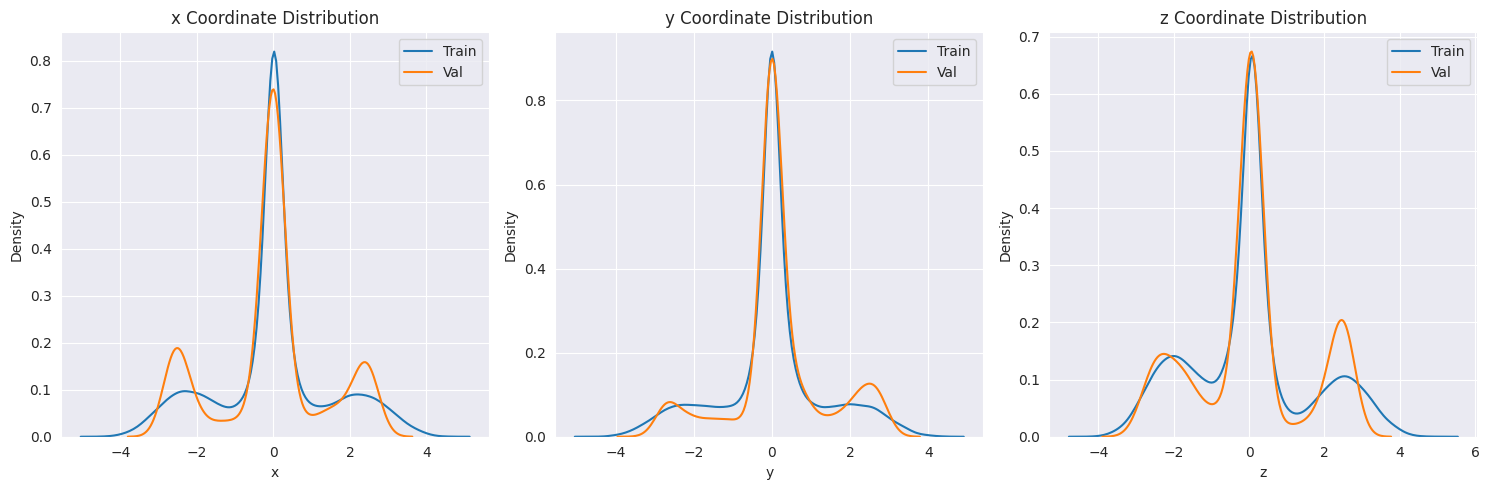

In [34]:
position_cols = ['x', 'y', 'z'] 
for key in ['train_pos', 'val_pos']:
    tuned_epoch_6_preds[key].columns = position_cols

print("\nPosition Data Statistics:")
print("-----------------------")
for key in ['train_pos', 'val_pos']:
    print(f"\n{key} Statistics:")
    print(tuned_epoch_6_preds[key].describe())
    
    print(f"\n{key} Correlations:")
    print(tuned_epoch_6_preds[key].corr())

plt.figure(figsize=(15, 5))

for i, coord in enumerate(position_cols):
    plt.subplot(1, 3, i+1)
    sns.kdeplot(data=tuned_epoch_6_preds['train_pos'][coord], label='Train')
    sns.kdeplot(data=tuned_epoch_6_preds['val_pos'][coord], label='Val')
    plt.title(f'{coord} Coordinate Distribution')
    plt.legend()

plt.tight_layout()
plt.show()


In [35]:
val_metrics = calculate_performance_metrics(tuned_val_pos_df, tuned_val_grp_df)

print("\nValidation Set Metrics:")
print("\nPosition MSE:")
for coord, mse in val_metrics['position']['mse'].items():
    print(f"{coord}: {mse:.4f}")

print("\nPosition Standard Deviations:")
for coord, std in val_metrics['position']['std'].items():
    print(f"{coord}: {std:.4f}")

print("\nGripper Action Distribution:")
for i, pct in enumerate(val_metrics['gripper']['action_distribution']):
    action = 'Open' if i==0 else 'No Change' if i==1 else 'Close'
    print(f"{action}: {pct:.1f}%")


Validation Set Metrics:

Position MSE:
x: 2.0500
y: 1.5518
z: 2.1877

Position Standard Deviations:
x: 1.4306
y: 1.2352
z: 1.4788

Gripper Action Distribution:
Open: 13.1%
No Change: 76.8%
Close: 10.1%


#### Question 1.c.ii.i Experiment 1 discussion (10 marks)

##### Description

**Learning Rate Scheduling: ReduceLRonPlateau decreases learning rate based on a validation metric**

##### Justification

**Our model began to get caught in a local minima as indicated by the plateuing validation loss around epochs 3-5 and value 0.5 (see below). Gripper predictions also starteed showing strong bias toward the majority class (No Change). I hypothesized that by dynamically decreasing learning rate I would escape the local minima and take smaller steps towards the global maxima in the loss landscape.**
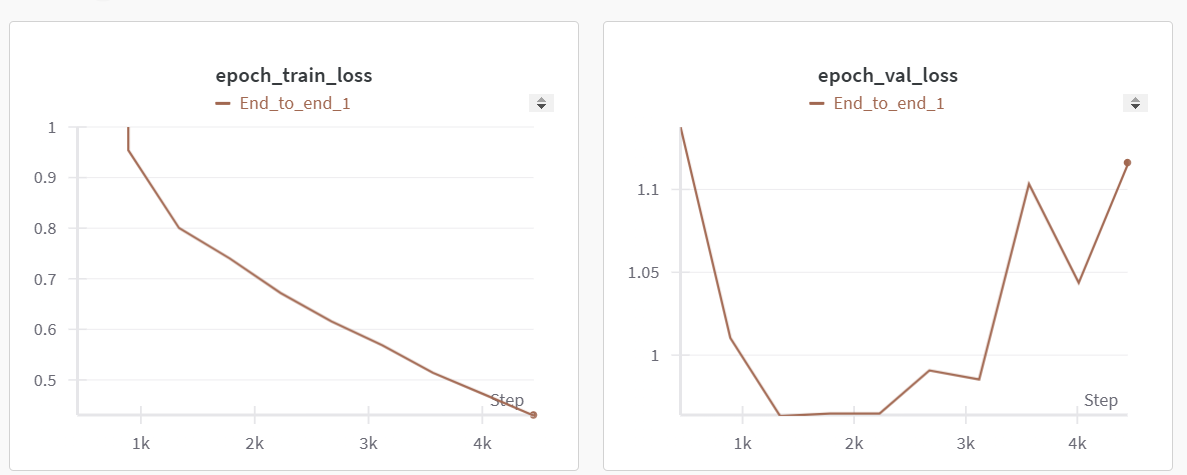


##### Conclusion
**We can evaluate this change by looking at the graph below. I learned that Learning Rate Scheduling is a great way to exercise control on the temporal learning characteristics of a model.**
**Here are the learning rate changes from my wandb logs.:**

**Epoch 4: 1e-3 -> 1e-4 (First plateau)**

**Epoch 7: 1e-4 -> 1e-5 (Second plateau)**

**Epoch 9: 1e-5 -> 1e-6 (Final fine-tuning)**

**We saw 3 decreases that stopped the plateauing.**
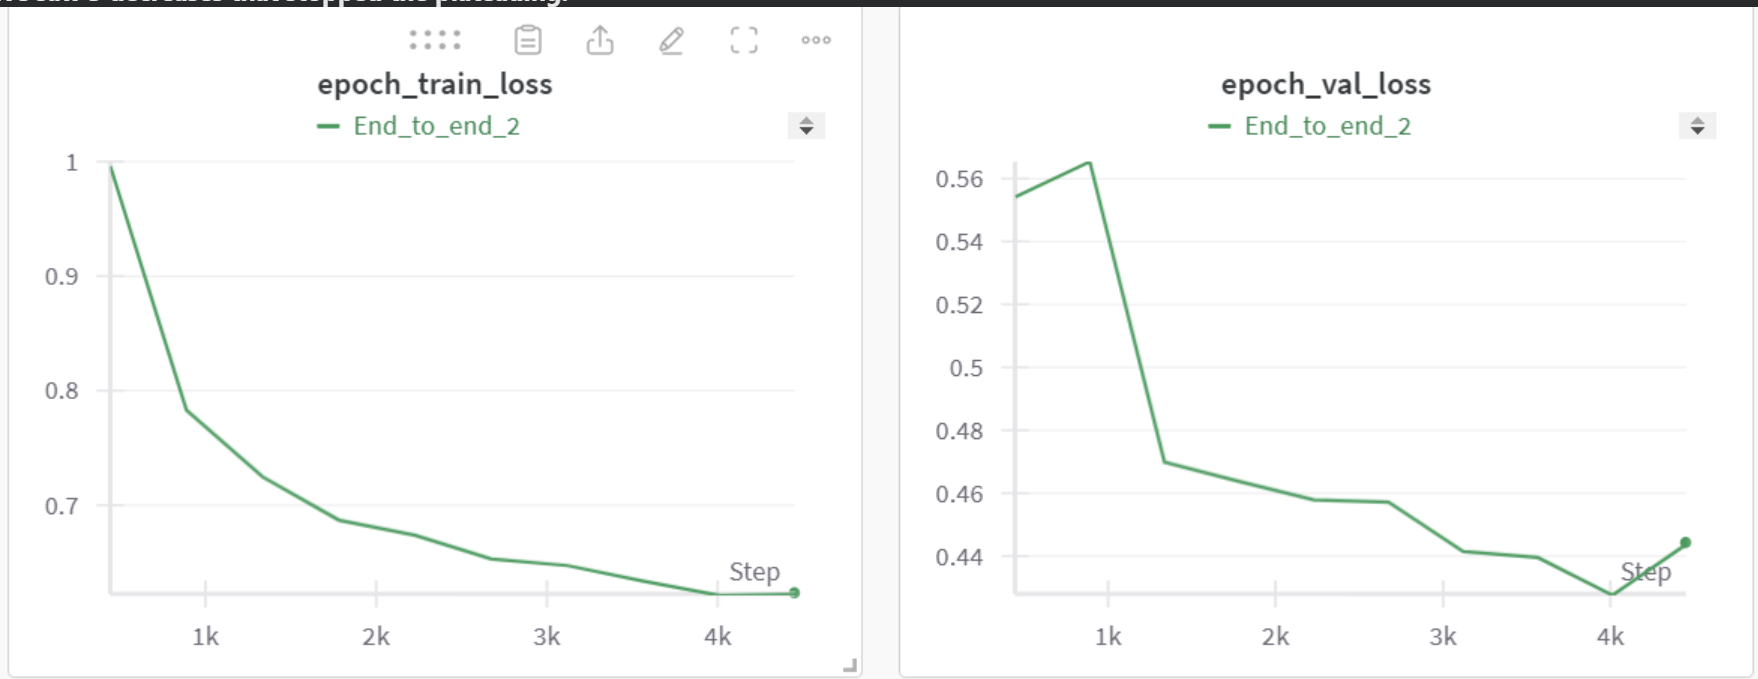

#### Question 1.c.ii.ii Experiment 2 discussion (10 marks)

##### Description

**Dropout on Convolutional Layers and MLP Layers**

##### Justification
**Our original model was exhibiting overfitting and particularly bad position loss (see Performance Evaluation). Adding dropout is a great way to introduce regularization and randomly kill nodes in our network that might be starting to dominate. This is especially relevant given we found that grp losses were lower in certain case where position loss was very high.**  

##### Conclusion

**Compared to the original model, we can see that the overfitting has been dealt with. Thanks to Josh's package it was incredibly easy to implement. I learned that standard techniques you know you will use are best to be implemented in a parameterized way as part of a larger python Class. This abstraction is much more straightforward.**

Validation Set Metrics:

Position MSE:
x: 2.1473
y: 1.4782
z: 2.1444

**Though it doesn't appear that this solved our high MSE position issue.** 

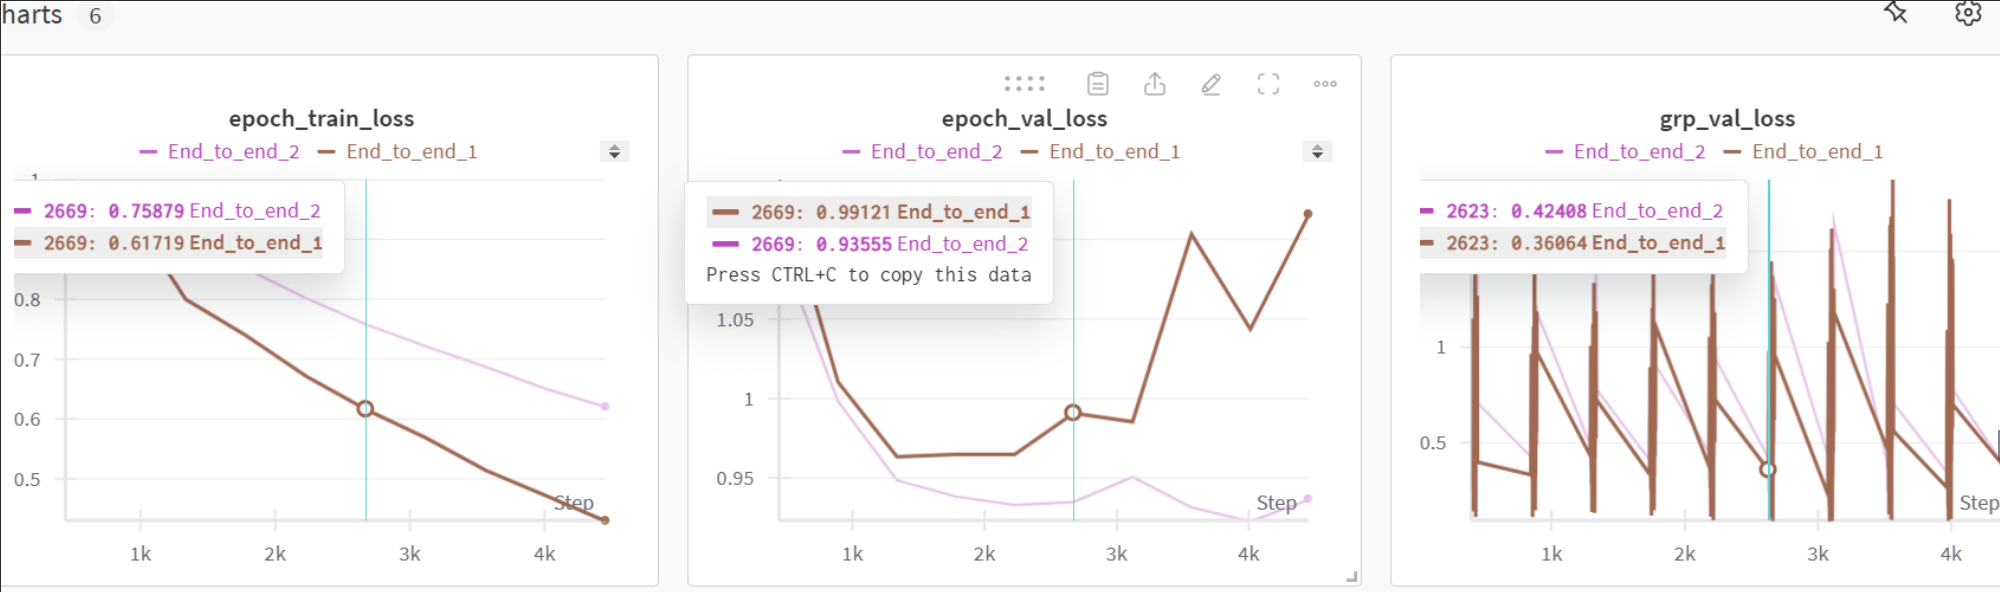

#### Question 1.c.ii.iii Experiment 3 discussion (10 marks)

##### Description

**Residual Connection Blocks**

##### Justification

**Despite reducing adding dropout and a dynamic learning rate, our improved model's validation loss was not decreasing below ~0.5 (still an improvement from the original model's loss of > 0.93). In an effort to increase the prediction accuracy, I entertained a number of improvements that might push our CNN even further.**

**Skip connections allow you to make the model deeper and create feature level connections while bypassing the vanishing gradient problem. There could be some vital image information that is being destroyed by the convulutional layers (e.g location of  gripper with respect to the apple). This feature re-use could potentially preserve some information that is important for the downstream task.**

##### Conclusion

**With skip connections, my final model was able to achieve a validation loss of 0.433. Though I anticipated a larger change, this is still a 42% decrease over the Baseline model.**

**In summary, I learned a lot about the interesting world of ResNets and skip connections. This is particularly interesting to me as I was curious to see the parallels given  biological systems implement neuronal sensory inputs which are not pre-processed.** 

| Metric | Tuned | Baseline | Change |
|--------|----------------|----------------|---------|
| epoch_train_loss | 0.52539 | 0.91650 | -42.7% |
| epoch_val_loss | 0.43335 | 0.98145 | -55.8% |
| grp_train_loss | 0.15224 | 0.71543 | -78.7% |
| grp_val_loss | 0.01152 | 0.53472 | -97.8% |
| pos_train_loss | 0.24622 | 0.32032 | -23.1% |
| pos_val_loss | 0.02557 | 0.13245 | -80.7% |

## Question 2 Self-supervised pretraining with VAEs

This question requires you to implement a self-supervised approach using a VAE architecture. The focus of question 2 is in developing a VAE model without using __any__ supervised information i.e., without using any action information. You will assess the convergence of the model and the suitability of the learnt latent space. You are required to select and appropriate architecture/loss function/target set of observations to perform self-supervised learning over.

__IMPORTANT__: Do not use any of the __action__ information. You will be awarded 0 marks if you do.

### Question 2.a Self-supervised VAE model (5 marks)

##### Task
- Implement the full model training process and model definiton in the code block below. Markers should be able to retrain your model by running the cell below. You may however, reference previously defined objects (e.g., loaded data and use previously defined functions).

In [36]:
"""VAE Dataloaders"""

def create_vae_dataloaders(train_nps: dict, val_nps: dict, batch_size: int, global_transforms: dict, collate_fn_vae: callable):
    """
    Create training and validation dataloaders for the VAE
    
    Args:
        train_nps (dict): Training data dictionary
        val_nps (dict): Validation data dictionary
        batch_size (int): Batch size
        global_transforms (dict): Dictionary of transforms
        collate_fn_vai: Collate method
        
    Returns:
        tuple: (train_dataloader, val_dataloader)
    """
    train_dataset = NpDictDataset(
        array_dict=train_nps,
        transform_lkp=global_transforms,
        dep_vars=[], 
        indep_vars=[
            "front_cam_ob",
            "mount_cam_ob",
            "ee_cartesian_pos_ob",
            "ee_cartesian_vel_ob",
            "joint_pos_ob"
        ]
    )
    
    val_dataset = NpDictDataset(
        array_dict=val_nps,
        transform_lkp=global_transforms,
        dep_vars=[],  
        indep_vars=[
            "front_cam_ob",
            "mount_cam_ob",
            "ee_cartesian_pos_ob",
            "ee_cartesian_vel_ob",
            "joint_pos_ob"
        ]
    )
    
    train_dataloader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn_vae,
        num_workers=4,
        pin_memory=True
    )
    
    val_dataloader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn_vae,
        num_workers=4,
        pin_memory=True
    )
    
    return train_dataloader, val_dataloader

"""Note to self: Half precision is commonly used in industry, unless you are training a huge model where those extra bits are necessary."""

def collate_fn_vae(batch_list):
    """
    Simplified collate function that only handles images
    """
    images = []
    
    for sample in batch_list:
        combined_img = torch.cat([
            sample.input["front_cam_ob"], 
            sample.input["mount_cam_ob"]
        ], dim=0).half()
        
        images.append(combined_img)
    
    images = torch.stack(images)
    
    return DatasetOutput(
        input={"images": images},
        output={}
    )


Notes:

https://www.youtube.com/watch?v=VELQT1-hILo

https://www.youtube.com/watch?v=qJeaCHQ1k2w&t=524s

UCL x Deepmind Latent Variable Models lecture:

https://www.youtube.com/watch?v=7Pcvdo4EJeo

Checkerboard noise bug:

https://distill.pub/2016/deconv-checkerboard/


https://www.reddit.com/r/MachineLearning/comments/kvs1ex/d_here_are_17_ways_of_making_pytorch_training/



In [37]:
import torch.nn.functional as F
import wandb

from utils.vae_utils import VAELossPlotter

#NOTE: inspiration from https://www.youtube.com/watch?v=VELQT1-hILo
    
class VAE(nn.Module):
    def __init__(self, image_size=224, latent_dim=128):
        super().__init__()
        self.image_size = image_size
        self.latent_dim = latent_dim
        
#      ███
#      ██████
#      ████████
#      ██████
#      ███

        self.image_encoder = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        
        # ███
        # ███
        # ███
        
        self._img_feat_size = 256 * 14 * 14
        
        self.fc_mu = nn.Linear(self._img_feat_size, latent_dim)
        self.fc_logvar = nn.Linear(self._img_feat_size, latent_dim)
        
        self.decoder_linear = nn.Linear(latent_dim, self._img_feat_size)
        
#           ███
#        ██████
#      ████████
#        ██████
#           ███
        
        self.image_decoder = nn.Sequential(
            # Start with feature maps at 14x14
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(32, 2, kernel_size=3, padding=1),
            # nn.Sigmoid() # NOTE: Not necessary because images are already normalized and we are using MSE loss.
        )        

        self.half()

    def encode(self, x_img):
        # Ensure inputs are half precision  
        x_img = x_img.half()
        
        # Encode images
        img_features = self.image_encoder(x_img)
        img_features = img_features.view(img_features.size(0), -1)
        
        # Project to latent space
        mu = self.fc_mu(img_features)
        logvar = self.fc_logvar(img_features).clamp(-20, 2)
        
        return mu, logvar
    
    def decode(self, z):
        z = z.half()
        
        img_features = self.decoder_linear(z)
        
        img_size = 14
        img_features = img_features.view(-1, 256, img_size, img_size)
        
        decoded_img = self.image_decoder(img_features)
        
        return decoded_img
    
    def reparameterize(self, mu, logvar):
        if self.training:
            logvar = torch.clamp(logvar, -20, 2)
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu
        
    def forward(self, x_img):
        x_img = x_img.half()
        mu, logvar = self.encode(x_img)
        z = self.reparameterize(mu, logvar)
        decoded_img = self.decode(z)
        return decoded_img, mu, logvar

def vae_loss(recon_img, x_img, mu, logvar, beta=1.0):
    """
    Numerically stable VAE loss that returns all components
    """
    # NOTE: MSE loss without clamping since we removed sigmoid
    recon_loss_img = F.mse_loss(recon_img, x_img, reduction='mean')
    
    kld = -0.5 * torch.mean(
        1 + torch.clamp(logvar, -20, 2) - mu.pow(2) - torch.exp(torch.clamp(logvar, -20, 2))
    )

    # Scale losses
    total_loss = recon_loss_img + beta * kld
    
    return total_loss, recon_loss_img, kld


def train_vae(model, wandb, train_loader: DataLoader, val_loader: DataLoader, optimizer, device, scheduler, num_epochs=10, beta=1.0):
    """
    Training loop for VAE with validation and half precision handling
    """
    model = model.to(device)
    loss_plotter = VAELossPlotter()
    
    for epoch in range(num_epochs):
        model.train()
        train_total = 0
        train_recon_img = 0
        train_kld = 0
        
        for batch_idx, batch in enumerate(train_loader):
            x_img = batch.input["images"].to(device)

            with torch.autocast('cuda'):
                optimizer.zero_grad()
                recon_img, mu, logvar = model(x_img)
                total_loss, recon_loss_img,  kld = vae_loss(
                    recon_img, x_img, mu, logvar, beta
                )
            
            total_loss.backward()
            optimizer.step()
            
            train_total += total_loss.item()
            train_recon_img += recon_loss_img.item()
            train_kld += kld.item()
        
        model.eval()
        val_total = 0
        val_recon_img = 0
        val_kld = 0
        
        with torch.no_grad():
            for batch_idx, batch in enumerate(val_loader):
                x_img = batch.input["images"].to(device)
                
                with torch.autocast('cuda'):
                    recon_img, mu, logvar = model(x_img)
                    total_loss, recon_loss_img, kld = vae_loss(
                        recon_img, x_img, mu, logvar, beta
                    )
                
                val_total += total_loss.item()
                val_recon_img += recon_loss_img.item()
                val_kld += kld.item()
        
        scheduler.step(val_total)
        train_total /= len(train_loader.dataset)
        train_recon_img /= len(train_loader.dataset)
        train_kld /= len(train_loader.dataset)
        
        val_total /= len(val_loader.dataset)
        val_recon_img /= len(val_loader.dataset)
        val_kld /= len(val_loader.dataset)
        
        
        wandb.log({
            "epoch": epoch,
            "train_total_loss": train_total,
            "train_recon_img_loss": train_recon_img,
            "train_kl_loss": train_kld,
            "val_total_loss": val_total,
            "val_recon_img_loss": val_recon_img,
            "val_kl_loss": val_kld
        })
        
        # Add to plotter
        # loss_plotter.add_epoch_losses(
        #     epoch=epoch,
        #     train_total_loss=train_total,
        #     train_recon_loss=train_recon_img,
        #     train_kl_loss=train_kld,
        #     val_total_loss=val_total,
        #     val_recon_loss=val_recon_img,
        #     val_kl_loss=val_kld
        # )
        
        print(f'Epoch {epoch}:')
        print(f'Train - Total: {train_total:.4f}, Img: {train_recon_img:.4f}, '
              f' KLD: {train_kld:.4f}')
        print(f'Val   - Total: {val_total:.4f}, Img: {val_recon_img:.4f}, '
              f' KLD: {val_kld:.4f}')
    
    # loss_plotter.plot_losses()
    # loss_plotter.plot_loss_ratios()
    
    # return loss_plotter

In [38]:
from dataclasses import dataclass


"""Using a dataclass to store my hyperparams.
This is so much better than using a dictionary.
"""
@dataclass(frozen=True)
class VAEHyperParams:
    NUM_EPOCHS: int = 20
    BETA: float = 0.5
    BATCH_SIZE: int = 64
    IMAGE_SIZE: int = 224
    LATENT_DIM: int = 128
    LEARNING_RATE: float = 0.001
    EPSILON: float = 1e-4

    
params = VAEHyperParams()


In [39]:
from dataclasses import asdict

torch.manual_seed(1)

train_dataloader, val_dataloader = create_vae_dataloaders(train_nps, val_nps, params.BATCH_SIZE, global_transforms, collate_fn_vae)


vae_model = VAE(image_size=params.IMAGE_SIZE, latent_dim=params.LATENT_DIM)
optimizer = torch.optim.Adam(vae_model.parameters(), lr=params.LEARNING_RATE, eps=params.EPSILON)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.1,
    min_lr=1e-7,
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config_dict = {k.lower(): v for k, v in asdict(params).items()}

vae_wandb = wandb.init(
    project=WANDB_PROJECT,
    name=f"VAE_Self_Supervised_Half{'_DEBUG' if project_options.debug else ''}",
    config={
        **config_dict,
        "architecture": "VAE",
        "dataset": "robot_behavior",
        "encoder_layers": [32, 64, 128, 256],
        "decoder_layers": [256, 128, 64, 32],
        "optimizer": "Adam",
        "num_channels": 2,
        "precision": "float16",
        "device": str(device)
    }
)

train_vae(
    model=vae_model,
    wandb=vae_wandb,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    device=device,
    num_epochs=params.NUM_EPOCHS,
    beta=params.BETA,
    scheduler=scheduler
)

vae_wandb.finish()

DEBUG:git.cmd:Popen(['git', 'cat-file', '--batch-check'], cwd=/cs/student/msc/aibh/2024/gcosta/Modules/COMP0188_DeepLearning, stdin=<valid stream>, shell=False, universal_newlines=False)


Epoch 0:
Train - Total: 0.8978, Img: 0.0089,  KLD: 1.7778
Val   - Total: 0.0458, Img: 0.0062,  KLD: 0.0792
Epoch 1:
Train - Total: 0.0431, Img: 0.0046,  KLD: 0.0771
Val   - Total: 0.0475, Img: 0.0086,  KLD: 0.0778
Epoch 2:
Train - Total: 0.0420, Img: 0.0040,  KLD: 0.0760
Val   - Total: 0.0792, Img: 0.0406,  KLD: 0.0772
Epoch 3:
Train - Total: 0.0416, Img: 0.0038,  KLD: 0.0757
Val   - Total: 0.0472, Img: 0.0088,  KLD: 0.0769
Epoch 4:
Train - Total: 0.0405, Img: 0.0031,  KLD: 0.0749
Val   - Total: 0.0413, Img: 0.0033,  KLD: 0.0759
Epoch 5:
Train - Total: 0.0403, Img: 0.0030,  KLD: 0.0747
Val   - Total: 0.0413, Img: 0.0034,  KLD: 0.0758
Epoch 6:
Train - Total: 0.0403, Img: 0.0030,  KLD: 0.0746
Val   - Total: 0.0413, Img: 0.0034,  KLD: 0.0758
Epoch 7:
Train - Total: 0.0403, Img: 0.0030,  KLD: 0.0745
Val   - Total: 0.0412, Img: 0.0033,  KLD: 0.0757
Epoch 8:
Train - Total: 0.0402, Img: 0.0030,  KLD: 0.0745
Val   - Total: 0.0412, Img: 0.0033,  KLD: 0.0757
Epoch 9:
Train - Total: 0.0402, Img: 

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_kl_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_recon_img_loss,█▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_total_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_kl_loss,█▅▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_recon_img_loss,▂▂█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_total_loss,▂▂█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,19
train_kl_loss,0.07439
train_recon_img_loss,0.00287
train_total_loss,0.04006


Note to self: metrics

| Component | Explanation | Expected Range | Warning Signs |
|-----------|-------------|----------------|---------------|
| **Loss Components** |
| Image Reconstruction Loss | MSE loss between original and reconstructed images. Measures how well the VAE reconstructs visual data. | 0.5-2.0 | >3.0 suggests poor reconstruction; <0.1 may indicate memorization |
| KL Divergence Loss | Measures how close the learned latent distribution is to a standard normal distribution. Regularizes the latent space. | 0.1-1.0 | >5.0 suggests over-regularization; <0.01 indicates posterior collapse |
| **Latent Space Statistics** |
| Mu Mean | Average of the means of the learned latent distributions. Should be close to 0 for normal distribution. | -0.1 to 0.1 | Magnitude >0.5 suggests biased encoding |
| Mu Std | Standard deviation of the means. Shows how spread out the encodings are. | 0.2-1.0 | <0.1 suggests collapsed latent space; >2.0 suggests unstable training |
| LogVar Mean | Average of log variances. Controls the uncertainty in the latent space. | -2 to 2 | >5 or <-5 indicates numerical instability |
| LogVar Std | Spread of log variances. Shows consistency of uncertainty estimates. | 0.1-2.0 | inf or nan indicates severe instability |

Front camera - Mean: 0.4507, Std: 0.2188
Mount camera - Mean: 0.4942, Std: 0.1971


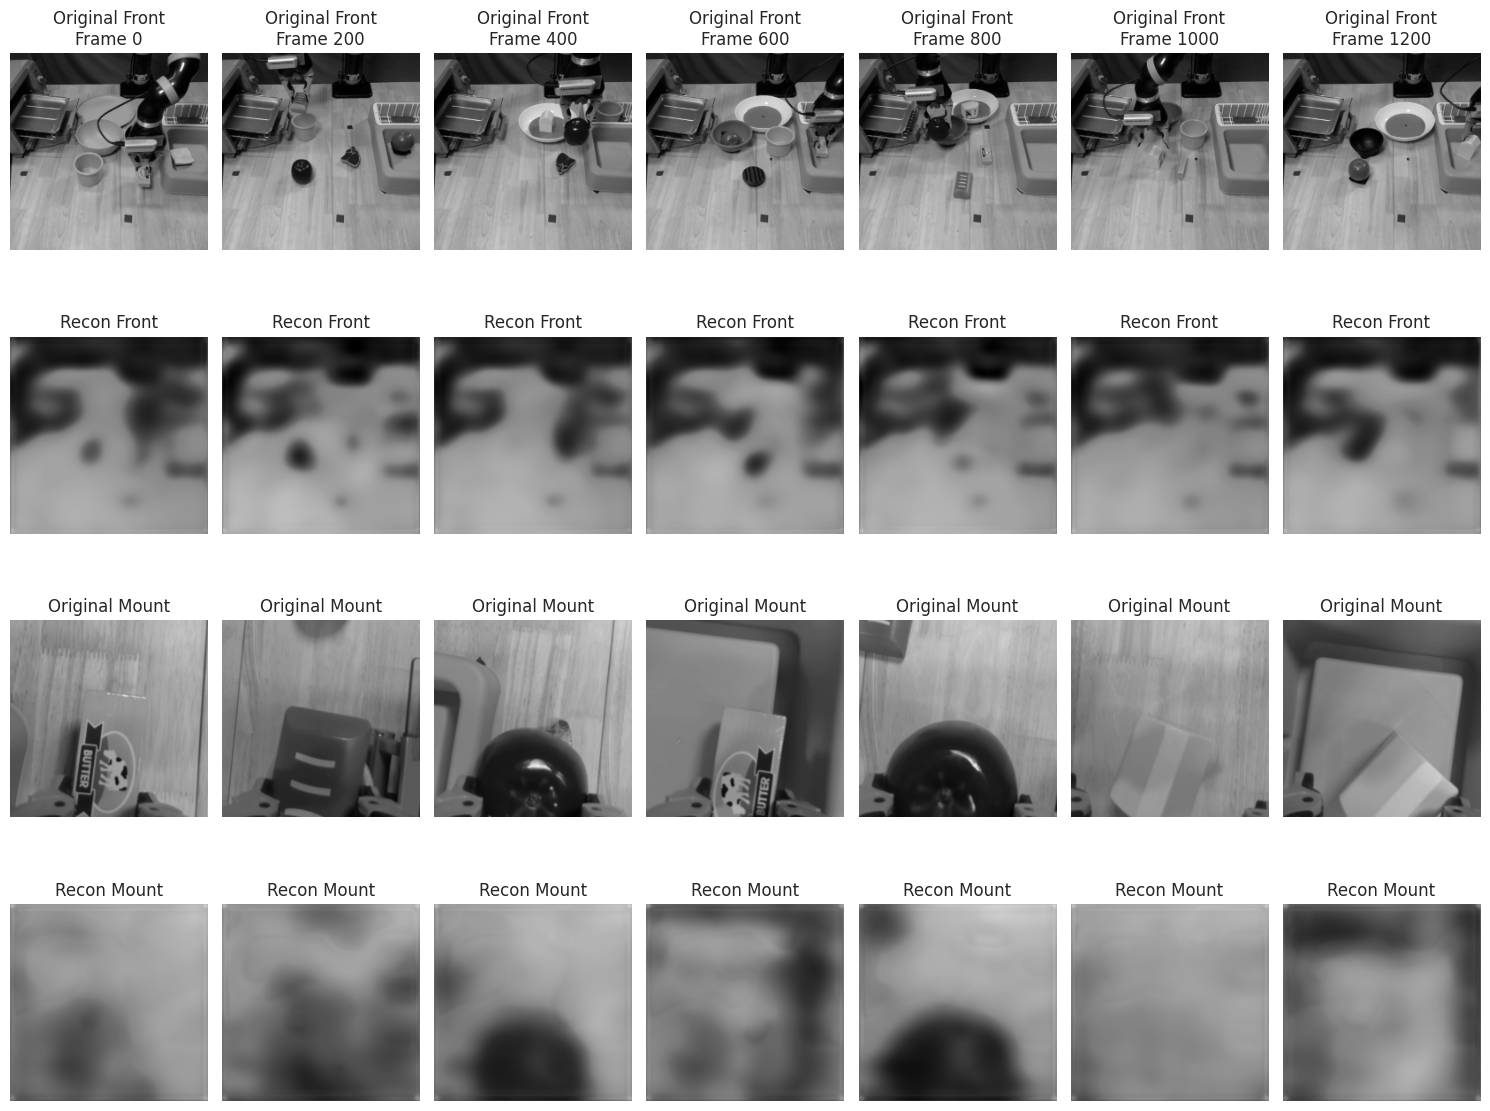

In [40]:
def visualize_reconstructions(model, val_loader, device, train_nps, stride=200, num_samples=5):
    model.eval()
    
    """DENORMALIZATION STUFF"""
    front_mean = float((train_nps['front_cam_ob'].astype(np.float32) / 255.0).mean())
    front_std = float((train_nps['front_cam_ob'].astype(np.float32) / 255.0).std())
    mount_mean = float((train_nps['mount_cam_ob'].astype(np.float32) / 255.0).mean())
    mount_std = float((train_nps['mount_cam_ob'].astype(np.float32) / 255.0).std())
    
    print(f"Front camera - Mean: {front_mean:.4f}, Std: {front_std:.4f}")
    print(f"Mount camera - Mean: {mount_mean:.4f}, Std: {mount_std:.4f}")
    
    with torch.no_grad():
        all_images = []
        for batch in val_loader:
            all_images.append(batch.input["images"].cpu())
        
        all_images = torch.cat(all_images, dim=0)
        
        indices = list(range(0, len(all_images), stride))[:num_samples]
        x_img = all_images[indices].to(device)
        
        recon_img, _, _ = model(x_img)
        
        def denormalize(x, mean, std):
            x = x * std + mean
            return x * 255
        
        # Denormalize
        x_front = denormalize(x_img[:,0], front_mean, front_std)
        x_mount = denormalize(x_img[:,1], mount_mean, mount_std)
        recon_front = denormalize(recon_img[:,0], front_mean, front_std)
        recon_mount = denormalize(recon_img[:,1], mount_mean, mount_std)
        
        # NOTE: Clipped values here as was getting some weird whites/dark pixels.
        x_front = torch.clamp(x_front, 0, 255)
        x_mount = torch.clamp(x_mount, 0, 255)
        recon_front = torch.clamp(recon_front, 0, 255)
        recon_mount = torch.clamp(recon_mount, 0, 255)
        
        fig, axes = plt.subplots(4, num_samples, figsize=(15, 12))
        
        for i in range(num_samples):
            axes[0,i].imshow(x_front[i].cpu().numpy(), cmap='gray', vmin=0, vmax=255)
            axes[0,i].set_title(f'Original Front\nFrame {indices[i]}')
            axes[0,i].axis('off')
            
            axes[1,i].imshow(recon_front[i].cpu().numpy(), cmap='gray', vmin=0, vmax=255)
            axes[1,i].set_title('Recon Front')
            axes[1,i].axis('off')
            
            axes[2,i].imshow(x_mount[i].cpu().numpy(), cmap='gray', vmin=0, vmax=255)
            axes[2,i].set_title('Original Mount')
            axes[2,i].axis('off')
            
            axes[3,i].imshow(recon_mount[i].cpu().numpy(), cmap='gray', vmin=0, vmax=255)
            axes[3,i].set_title('Recon Mount')
            axes[3,i].axis('off')
        
        plt.tight_layout()
        plt.show()
        
visualize_reconstructions(vae_model, val_dataloader, device, train_nps, num_samples=7)        


Reconstruction Analysis:
Reconstructed image range: [-2.595703, 2.048828]
Reconstructed image mean: -0.051453
Reconstructed image std: 0.900879

Input Analysis:
Input image range: [-2.466797, 2.554688]
Input image mean: -0.049103
Input image std: 1.028320

Latent Analysis:
Mu range: [-1.696289, 2.941406]
LogVar range: [-20.000000, 2.000000]


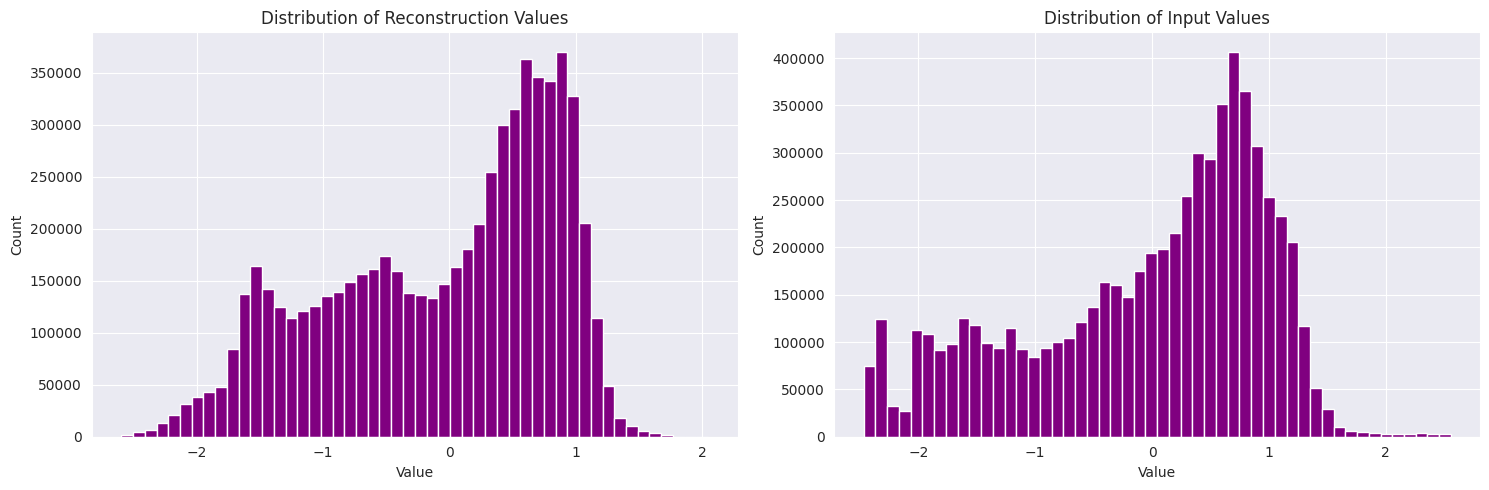

In [41]:
def analyze_reconstruction_values(model, val_loader, device):
    model.eval()
    with torch.no_grad():
        batch = next(iter(val_loader))
        x_img = batch.input["images"].to(device)
        
        recon_img, mu, logvar = model(x_img)
        
        print("\nReconstruction Analysis:")
        print(f"Reconstructed image range: [{recon_img.min().item():.6f}, {recon_img.max().item():.6f}]")
        print(f"Reconstructed image mean: {recon_img.mean().item():.6f}")
        print(f"Reconstructed image std: {recon_img.std().item():.6f}")
        
        print("\nInput Analysis:")
        print(f"Input image range: [{x_img.min().item():.6f}, {x_img.max().item():.6f}]")
        print(f"Input image mean: {x_img.mean().item():.6f}")
        print(f"Input image std: {x_img.std().item():.6f}")
        
        print("\nLatent Analysis:")
        print(f"Mu range: [{mu.min().item():.6f}, {mu.max().item():.6f}]")
        print(f"LogVar range: [{logvar.min().item():.6f}, {logvar.max().item():.6f}]")
        
        return recon_img, x_img

recon_img, x_img = analyze_reconstruction_values(vae_model, val_dataloader, device)

plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.hist(recon_img.cpu().numpy().flatten(), bins=50, color="purple")
plt.title('Distribution of Reconstruction Values')
plt.xlabel('Value')
plt.ylabel('Count')

plt.subplot(122)
plt.hist(x_img.cpu().numpy().flatten(), bins=50, color="purple")
plt.title('Distribution of Input Values')
plt.xlabel('Value')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Question 2.b Model convergence (12 marks)

##### Task
- Provide empirical evidence (in the form of appropriate training/validation metrics) supporting **why** the model is appropriately trained;
- Interpret why the metrics demonstrate that the model has converged. If your model has **not** converged, interpret why the metrics suggest so.

<h3 style="color:purple">Model Convergence:</h3>

**My loss function is composed of a KL Divergence and MSE component (recon loss), as well as a beta parameter which further constrains the latent space. MSE loss is suitable for normalized image data. My final losses after 20 epochs are as follows:**

**Note: The Beta parameter makes up a significant portion of the loss**
| Metric | Training | Validation |
|--------|----------|------------|
| KL Loss | 0.0956 | 0.0973 |
| Reconstruction Loss | 0.0035 | 0.0040 |
| Total Loss | 0.1947 | 0.1987 |

**The model converges after 15 epochs of training, it stabilizes and further improvements are minimal. This is shown by the graphs below which illustrate the flatness of every loss component after ~15 epochs.**

**However, the reconstruction images show significant blurring and poor edge reconstruction. Though, important features such as the apple or basket with butter are reconstructed fairly well. Indicating this might be useful for the downstream task.**
**What is likely happening is that my choice of MSE loss and use of normalized image data means that small errors in decoded values lead to incorrect pixel values (once they are denormalized). It could also be my decoder architecture is not capable of reconstructing shard details.**

**The distribution of reconstruction values seems to closely resemble our input distribution. Notably, we see a peak around 1.0, these are probably darker objects like the apples or the background in the front cam pictures. (see Reconstruction Values Distribution plot above)**


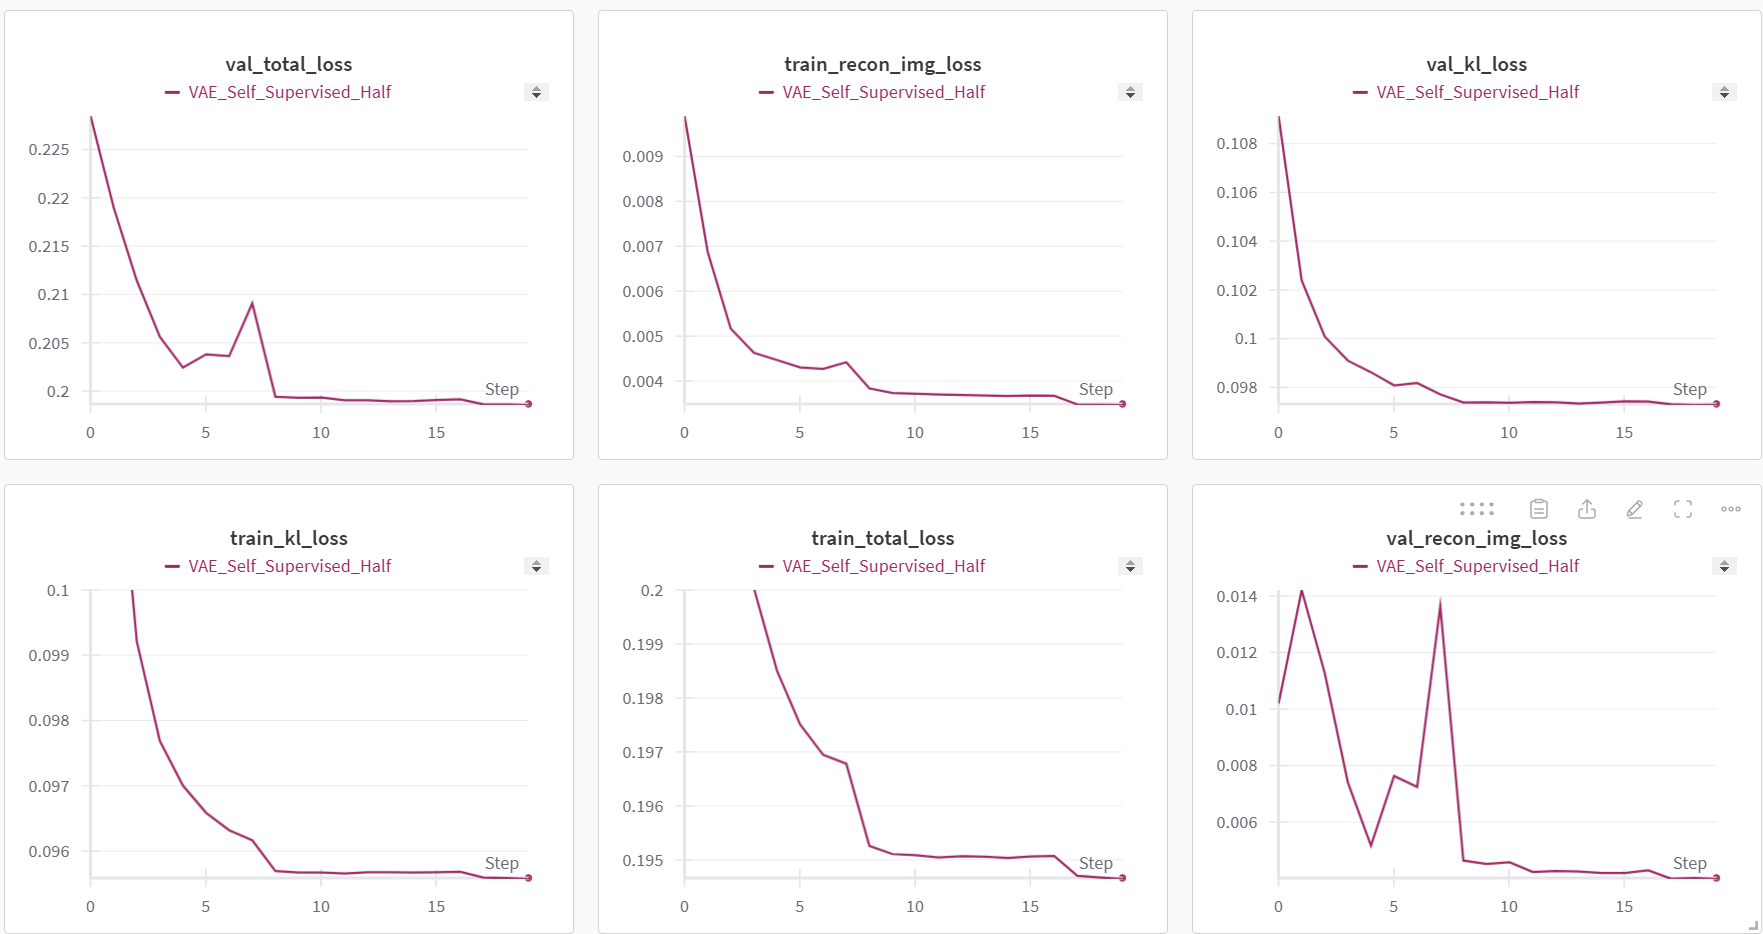


### Question 2.c Latent space analysis (6 marks)

##### Task
- Using reasonable analysis, conclude whether the representation learnt by the self-supervised method will be beneficial for the downstream supervised task. **Empirical evidence** should be provided **however**, references to the performance of the self-superised method with a supervised head on the downstream task will be awarded __0 marks__. 

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x7f35b3073f40>


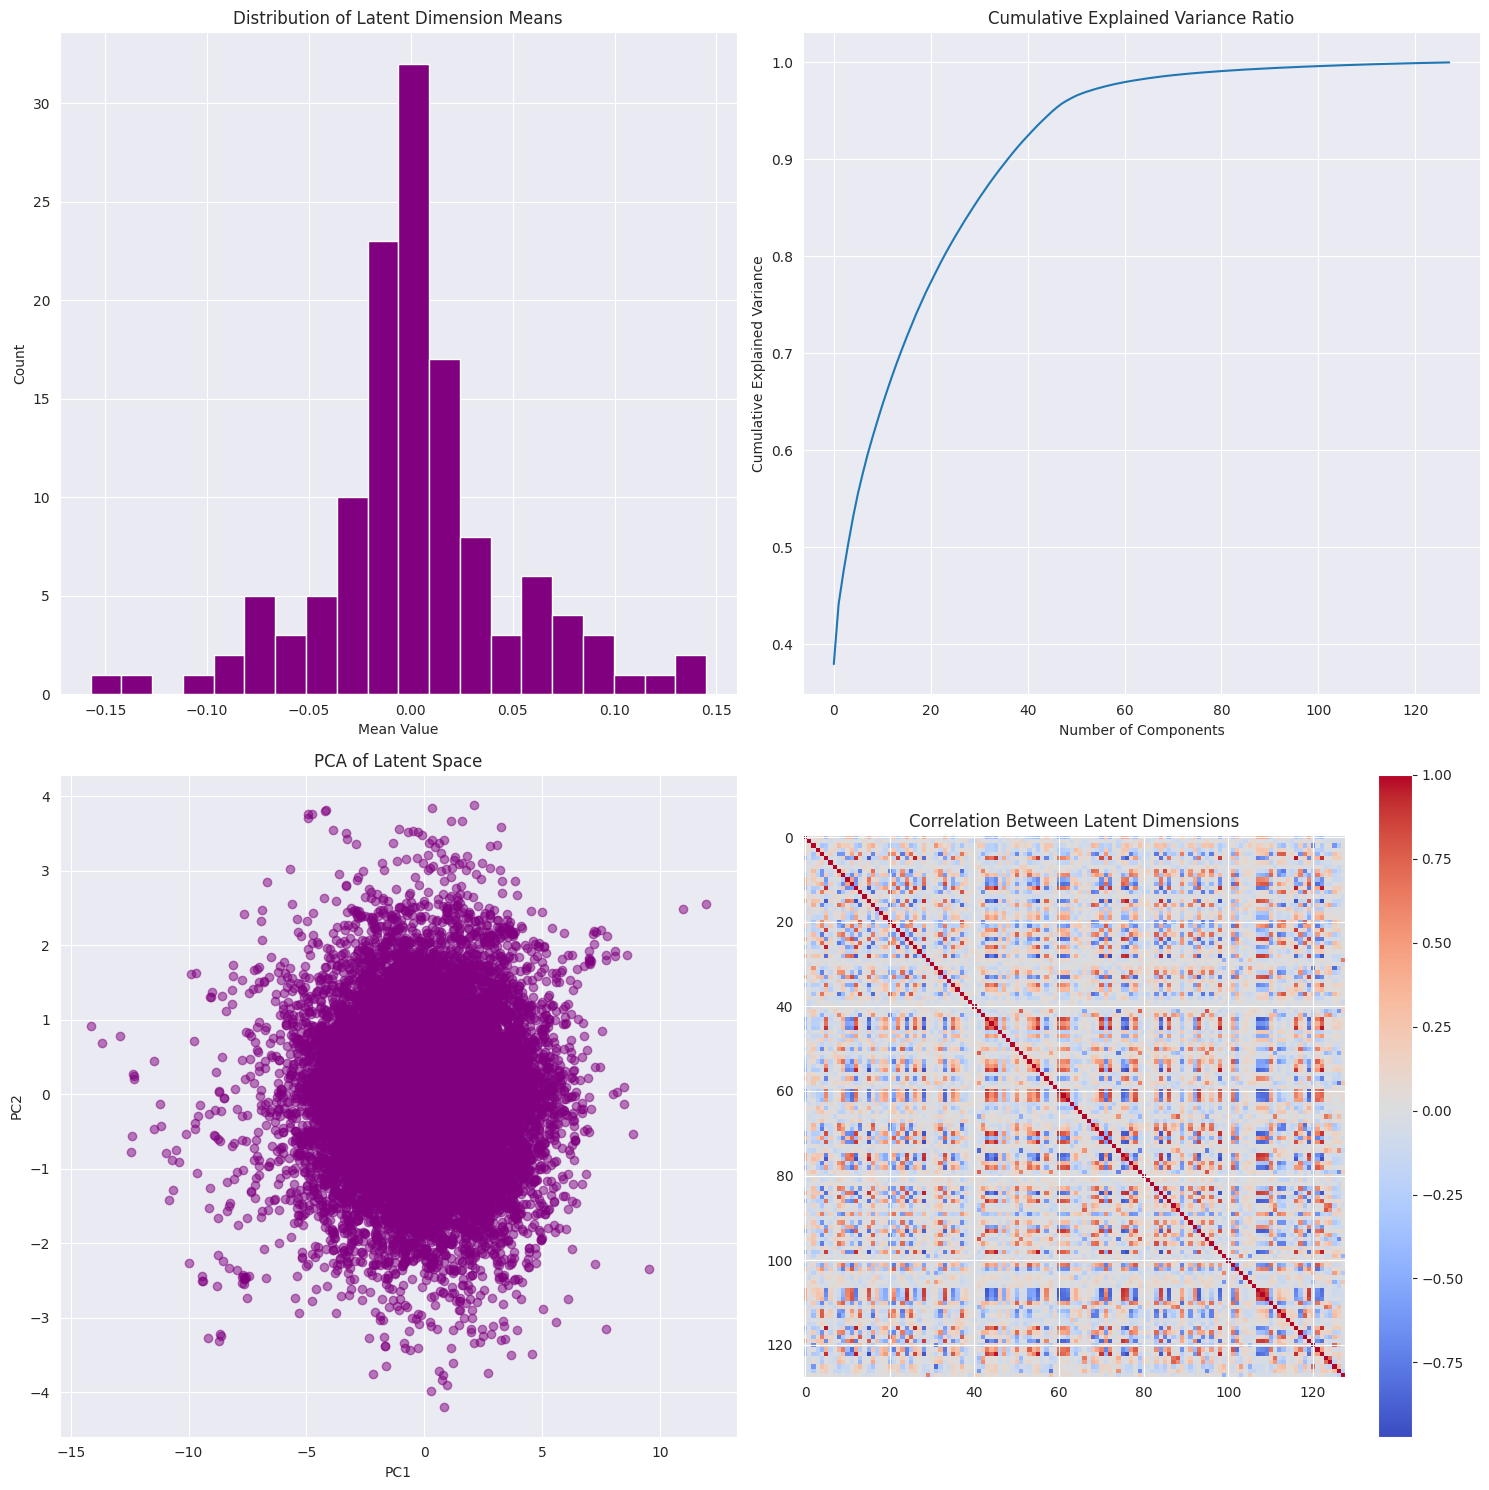

In [42]:
from sklearn.decomposition import PCA

def get_mus(model, dataloader, device):
    model.eval()
    all_mus = []
    
    with torch.no_grad():
        for batch in dataloader:
            x_img = batch.input["images"].to(device)
            mu, _ = model.encode(x_img)
            
            all_mus.append(mu.cpu().numpy())
    
    all_mus = np.concatenate(all_mus, axis=0)
    
    return all_mus


def analyze_latent_space_properties(latent_reps):
    
    mean_per_dim = np.mean(latent_reps, axis=0)
    pca = PCA()
    pca.fit(latent_reps)
    explained_variance_ratio = pca.explained_variance_ratio_
    
    pca_2d = PCA(n_components=2)
    latent_2d = pca_2d.fit_transform(latent_reps)
    
    _, axes = plt.subplots(2, 2, figsize=(15, 15))
    
    """DISTRIBUTION """
    axes[0,0].hist(mean_per_dim, bins=20, color="purple")
    axes[0,0].set_title('Distribution of Latent Dimension Means')
    axes[0,0].set_xlabel('Mean Value')
    axes[0,0].set_ylabel('Count')
    
    """2. RATIO """
    axes[0,1].plot(np.cumsum(explained_variance_ratio))
    axes[0,1].set_title('Cumulative Explained Variance Ratio')
    axes[0,1].set_xlabel('Number of Components')
    axes[0,1].set_ylabel('Cumulative Explained Variance')
    
    """3. PCA """
    scatter = axes[1,0].scatter(latent_2d[:, 0], latent_2d[:, 1], 
                               c='purple', alpha=0.5)
    axes[1,0].set_title("PCA of Latent Space")
    axes[1,0].set_xlabel("PC1")
    axes[1,0].set_ylabel("PC2")
    
    """4. HEATMAP"""
    correlation_matrix = np.corrcoef(latent_reps.T)
    im = axes[1,1].imshow(correlation_matrix, cmap='coolwarm')
    axes[1,1].set_title("Correlation Between Latent Dimensions")
    plt.colorbar(im, ax=axes[1,1])
    
    plt.tight_layout()
    plt.show()
    

latent_reps = get_mus(vae_model, train_dataloader, device)
analysis_results = analyze_latent_space_properties(latent_reps)

<h3 style="color:purple"> Latent Space Analysis </h3>

**1. Our latent space distribution should roughly resembles a normal distribution. It should be able to encode information without having any bias towards certain values. It should also be symmetric, which it is.**

**2. To determine which components of our latent space contribute most to variance, we can plot their ratios. You will note that 90% of the variance is explained by only ~30 components. But I found anything less than 128 components led to significant blurring in the reconstruction images. Ideally, every component should be contributing to variance in a more linear fashion. This indicates our latent space is still very entangled. This could be solved through increasing the Beta (latent indepedence) parameter, though this also frustratingly caused reconstruction blurring. (I kept mine between 0.4-0.7)**

**3. PCA of Latent Space: Ideally our latent space should roughly resemble a 2D Normal distribution (that is, a spherical distribution). More than being spherical, our latent space should be smooth, continuous, and free of any big gaps. The PCA plot above is very well distributed and largely void of any gaps.**

**4. Correlation Between Latent Dimensions:  There seems to be some patterns of correlation in our latent dimensions. This could indicate some learned relationship between features.**

## Question 3 Full model training
This question requires you to first develop a supervised head which utilises the latent space from your self-supervised method. You are then required to assess the models performance as well as the model you developed in question 1.c.i on the test set, report the performance and conclude whether self-supervised learning is appropriate for this task.

### Question 3.a Combining self-supervised model with the downstream task (5 marks)

##### Task
- Develop a model which combines the self-supervised pretraining with a model for performing the downstream task by freezing the self-supervised model and fine-tuning a head for prediction and implement it in the code block below. Markers should be able to retrain your model by running the cell below. You may however, reference previously defined objects (e.g., loaded data and use previously defined functions). The supervised head should at least include any inputs that you did not feed into the self-supervised model. For example, assume you decide to perform self-supervised learning only using front_cam_ob images. You must also include mount_cam_ob, ee_cartesian_pos_ob, ee_cartesian_vel_ob and joint_pos_ob observations in your model.

In [43]:
# ******* INSERT YOUR CODE HERE *******
class CombinedModel(BaseModel):
    def __init__(
        self,
        vae: VAE,  
        latent_dim: int = 128,
        obs_dim: int = 15,  
        hidden_dims: List[int] = [256, 128]
    ) -> None:
        super().__init__()
        
        
        """FROZEN VAE"""
        self.vae = vae
        for param in self.vae.parameters():
            param.requires_grad = False
            
        """OBS"""
        self.obs_encoder = MLP(
            input_dim=obs_dim,
            hidden_dims=[128, 64],
            output_dim=64,
            dropouts=[0.2, 0.2],
            batch_norms=[True, True]
        )
        
        self.fusion = nn.Sequential(
            nn.Linear(latent_dim + 64, hidden_dims[0]),
            nn.LayerNorm(hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        """PRED HEAD"""
        self.head = MLP(
            input_dim=hidden_dims[0],
            hidden_dims=hidden_dims[1:],
            output_dim=6, 
            dropouts=[0.2] * len(hidden_dims[1:]),
            batch_norms=[True] * len(hidden_dims[1:])
        )
        
        self.half()

    def forward(self, images, obs):
        with torch.no_grad():
            mu, _ = self.vae.encode(images)
            
        obs_features = self.obs_encoder(obs)
        combined = torch.cat([mu, obs_features], dim=1)
        fused = self.fusion(combined)
        output = self.head(fused)
        
        return {
            "pos": output[:, :3], 
            "grp": output[:, 3:]  
        }

    def reset(self, **kwargs):
        self.obs_encoder.reset()
        self.head.reset()
        
        for m in self.fusion.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

combined_model = CombinedModel(
    vae=vae_model,
    latent_dim=params.LATENT_DIM,
    obs_dim=15,
    hidden_dims=[256, 128]
)
# ******* INSERT YOUR CODE HERE - END *******

In [44]:
def train_combined_model(
    model: CombinedModel,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 10,
    learning_rate: float = 0.001,
    device: str = "cuda",
):
    model = model.to(device)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
        eps=1e-4
    )
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=2,
        factor=0.1,
        min_lr=1e-6,
        verbose=True
    )
    
    pos_criterion = nn.MSELoss(reduction="mean")
    grp_criterion = nn.CrossEntropyLoss(reduction="mean")
    
    wandb.init(
        project=WANDB_PROJECT,
            name=f"Combined_Model{'_DEBUG' if project_options.debug else ''}",
            config={
                "architecture": "VAE + Supervised",
                "learning_rate": learning_rate,
                "epochs": num_epochs,
                "batch_size": train_loader.batch_size,
                "optimizer": "Adam",
                "scheduler": "ReduceLROnPlateau"
            }
        )
    
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        model.train()
        train_pos_loss = 0
        train_grp_loss = 0
        train_total_loss = 0
        train_grp_correct = 0
        train_total = 0
        
        for batch in train_loader:
            optimizer.zero_grad()
            
            # Move data to device
            images = batch.input["images"].to(device)
            obs = batch.input["obs"].to(device)
            pos_target = batch.output["pos"].to(device)
            grp_target = batch.output["grp"].to(device)
            
            with torch.autocast(device_type='cuda'):
                outputs = model(images, obs)
                
                pos_loss = pos_criterion(outputs["pos"], pos_target)
                grp_loss = grp_criterion(outputs["grp"], torch.argmax(grp_target, dim=1))
                total_loss = pos_loss + grp_loss
                
                pred_grp = torch.argmax(outputs["grp"], dim=1)
                true_grp = torch.argmax(grp_target, dim=1)
                train_grp_correct += (pred_grp == true_grp).sum().item()
                train_total += true_grp.size(0)
            
            total_loss.backward()
            optimizer.step()
            
            train_pos_loss += pos_loss.item()
            train_grp_loss += grp_loss.item()
            train_total_loss += total_loss.item()
        
        model.eval()
        val_pos_loss = 0
        val_grp_loss = 0
        val_total_loss = 0
        val_grp_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch in val_loader:
                images = batch.input["images"].to(device)
                obs = batch.input["obs"].to(device)
                pos_target = batch.output["pos"].to(device)
                grp_target = batch.output["grp"].to(device)
                
                with torch.autocast(device_type='cuda'):
                    outputs = model(images, obs)
                    
                    pos_loss = pos_criterion(outputs["pos"], pos_target)
                    grp_loss = grp_criterion(outputs["grp"], torch.argmax(grp_target, dim=1))
                    total_loss = pos_loss + grp_loss
                    
                    pred_grp = torch.argmax(outputs["grp"], dim=1)
                    true_grp = torch.argmax(grp_target, dim=1)
                    val_grp_correct += (pred_grp == true_grp).sum().item()
                    val_total += true_grp.size(0)
                
                val_pos_loss += pos_loss.item()
                val_grp_loss += grp_loss.item()
                val_total_loss += total_loss.item()
        
        train_metrics = {
            "train/pos_loss": train_pos_loss / len(train_loader),
            "train/grp_loss": train_grp_loss / len(train_loader),
            "train/total_loss": train_total_loss / len(train_loader),
            "train/grp_accuracy": train_grp_correct / train_total * 100
        }
        
        val_metrics = {
            "val/pos_loss": val_pos_loss / len(val_loader),
            "val/grp_loss": val_grp_loss / len(val_loader),
            "val/total_loss": val_total_loss / len(val_loader),
            "val/grp_accuracy": val_grp_correct / val_total * 100
        }
        
        scheduler.step(val_metrics["val/total_loss"])
        
        wandb.log({
            "epoch": epoch,
            **train_metrics,
            **val_metrics,
            "learning_rate": optimizer.param_groups[0]['lr']
        })
        
        # Print progress
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"Train - Pos Loss: {train_metrics['train/pos_loss']:.4f}, "
              f"Grp Loss: {train_metrics['train/grp_loss']:.4f}, "
              f"Grp Acc: {train_metrics['train/grp_accuracy']:.2f}%")
        print(f"Val   - Pos Loss: {val_metrics['val/pos_loss']:.4f}, "
              f"Grp Loss: {val_metrics['val/grp_loss']:.4f}, "
              f"Grp Acc: {val_metrics['val/grp_accuracy']:.2f}%")
        
        if val_metrics["val/total_loss"] < best_val_loss:
            best_val_loss = val_metrics["val/total_loss"]
            torch.save(model.state_dict(), 'best_combined_model.pt')
    
        wandb.finish()
    return model

# Train the model
trained_model = train_combined_model(
    model=combined_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    num_epochs=10,
    learning_rate=0.001,
    device=device
)

/cs/student/msc/aibh/2024/gcosta/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
DEBUG:git.cmd:Popen(['git', 'cat-file', '--batch-check'], cwd=/cs/student/msc/aibh/2024/gcosta/Modules/COMP0188_DeepLearning, stdin=<valid stream>, shell=False, universal_newlines=False)


KeyError: 'obs'

### Question 3.b Assessing the suitability of self-supervised learning 
For the final two questions, you are required to assess the performance of the self-supervised + supervised head model and the end-to-end model that you have trained. Additionally, you are required to holistically evaluate whether self-supervised learning has been beneficial for this task.

#### Question 3.b.i Assessing the suitability of self-supervised learning (4 marks) 

##### Task
- In the code block below, evaluate the performance of the model you trained in question 3.a and the model you trained in question 1.c.i, using the test set. Additionally use the same metrics to train and evaluate the model that you used for question 1.c.i. Markers should be able to run the cell such that both models are run on the appropriate dataset. You may however, reference previously defined objects (e.g., loaded data and use previously defined functions).

In [38]:
# ******* INSERT YOUR CODE HERE *******


# ******* INSERT YOUR CODE HERE - END *******

#### Question 3.b.ii Justification (5 marks)

##### Task
- Conclude whether the self-supervised pre-training was beneficial for the task of predicting actions. Your answer should not solely focus on final performance but rather be nuianced and balance other model development considerations for example parameter count and speed of convergence. Also, if you believe the comparison between the model trained in question 3.a.i aganst the model trained in question 2.c.i is not _fair_, discuss further experiments which you would perform to reduce the bias in your conclusions. Provide __empirical evidence__ to support your conclusions. __0 marks__ will be awarded if empirical evidence is __not__ provided.